# Mapping Employee Satisfaction: Clustering, Prediction and Sentiment Insights

# 1	Business understanding 


ServiceFirst is a national organisation that services large equipment for corporate and private clients in Australia. They are a successful business with 25 years in the industry, boasting 250 employees within a multi-layered structure with various departments. This includes remote service staff and office-based support teams spread across regional offices nationwide. 

Unfortunately, during the pandemic, many employees resigned, leading to high recruitment costs and a loss of experience within the organisation. To address this issue, ServiceFirst initiated a project to better understand the reasons behind these resignations. 

A follow-up survey was conducted to monitor changes in employee satisfaction and address ongoing concerns. The survey collected the following information:

- Frequency of business travel,
- Level of education,
- Gender,
- Age,
- Monthly income,
- Total working years,
- Satisfaction score (based on the Organisational Climate Measure) (Patterson et al., 2005), and
- Open-ended feedback.

ServiceFirst’s overall aim is to reduce recruitment costs and minimise the loss of experienced employees by fostering a more positive organisational climate. Specifically, the goals of this second project are to gain a deeper understanding of the key drivers of employee satisfaction by:

1. Identifying clusters of employees with similar satisfaction levels and monthly income.
2. Creating a model to predict satisfaction levels based on various factors.
3. Conducting a sentiment analysis of open-ended feedback.

The data mining goals relevant to the business goals are provided in the following table:
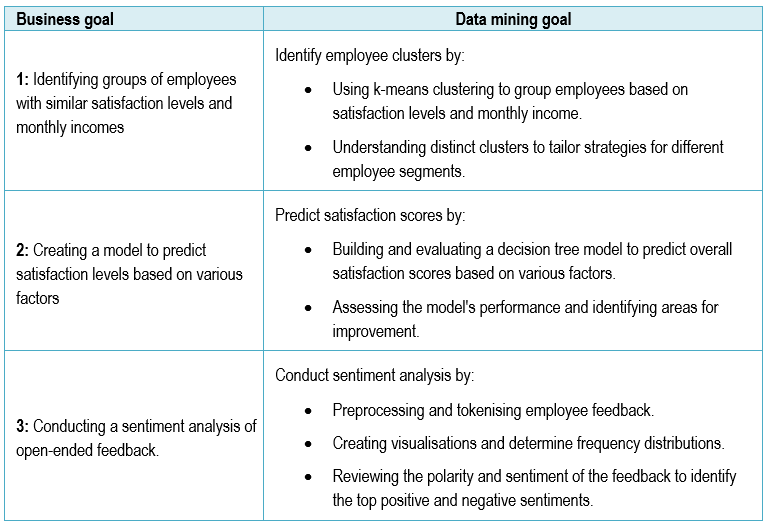


Please refer to report for further information 
****

# 2	Data understanding & 3 Data preparation

## 2.1 Import and view the data

The data that was provided is structured and was provided as a comma separated value (csv) file employee_satisfaction_data.csv.
The follow steps will be undertaken to gain a better understanding of the dataset.
 - Import the Pandas and NumPy libraries. (Numpy is required to perform mathematical functions and statistical analysis. Pandas is able to work with the large structured data tables which are csv files in this case. Pandas is built on top of Numpy so it inherits its performance benefits for numerical operations.)
 - Create a new variable to store the data as a DataFrame.
 - Import the data set 
 - Review the DataFrame 

In [2]:
# Import the necessary libraries.
import pandas as pd
import numpy as np

import warnings
warnings.filterwarnings('ignore')

# Import the data set and call the dataframe 'survey'
survey = pd.read_csv('employee_satisfaction_data.csv')

# Confirm if imported correctly, by viewing shape, column names and first five rows
print(survey.shape)
print(survey.columns) 
survey.head()

(142, 9)
Index(['Rowid', 'Business Travel', 'Education', 'Gender', 'Age',
       'MonthlyIncome (K)', 'Total Working Years', 'satisfaction_score',
       'Review'],
      dtype='object')


,Rowid,Business Travel,Education,Gender,Age,MonthlyIncome (K),Total Working Years,satisfaction_score,Review
0,1,Travel_Frequently,Higher Certicate,Female,50,6.60,22,32,"Stuck with low wages for years, management doe..."
1,96,Non-Travel,A Level,Female,32,1.57,0,64,"ServiceFirst is a great start for my career, l..."
2,2,Non-Travel,A Level,Male,19,2.40,1,68,"I'm learning a ton here, love it!"
3,53,Non-Travel,A Level,Female,20,2.07,1,61,"ServiceFirst is a great start for my career, l..."
4,97,Travel_Rarely,Masters,Female,55,15.97,27,100,"I've been with ServiceFirst for over a decade,..."


> The data has been imported correctly. The `survey` dataframe (df) has 9 columns (variables) and 142 rows of data

## 2.2 Describe data

In [2]:
# Review the size and data types of all the columns
survey.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 142 entries, 0 to 141
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Rowid                142 non-null    int64  
 1   Business Travel      142 non-null    object 
 2   Education            142 non-null    object 
 3   Gender               142 non-null    object 
 4   Age                  142 non-null    int64  
 5   MonthlyIncome (K)    142 non-null    float64
 6   Total Working Years  142 non-null    int64  
 7   satisfaction_score   142 non-null    int64  
 8   Review               140 non-null    object 
dtypes: float64(1), int64(4), object(4)
memory usage: 10.1+ KB


> The data set consists of three data types (`object` or numbers as either `float64` and `int64`).
> The table below provides further information regarding variables of the 'survey' dataframe.
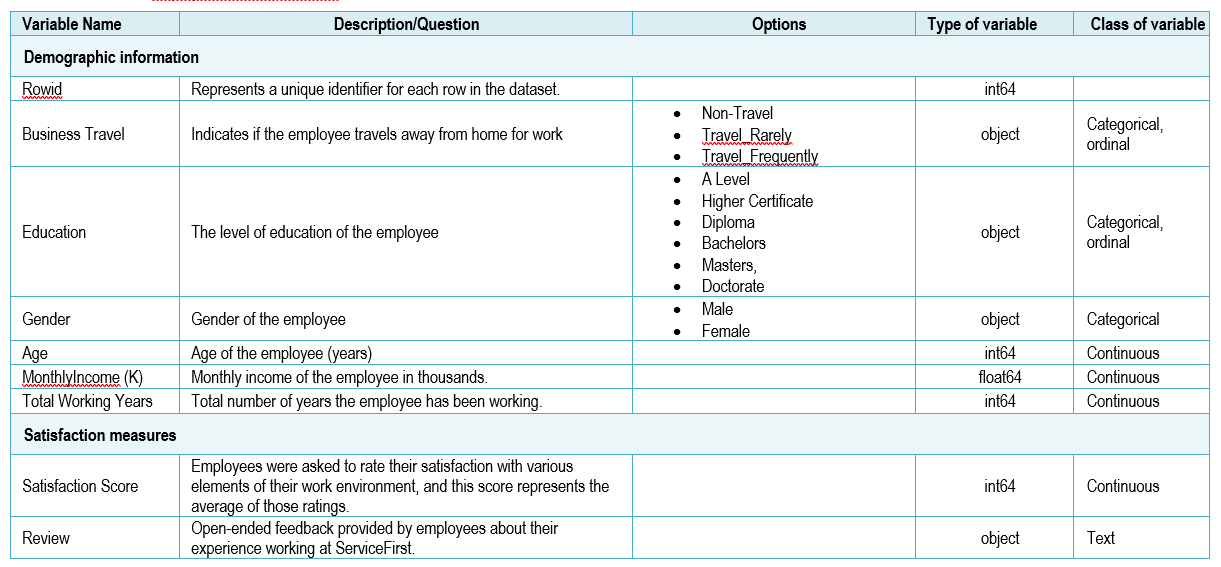
> As shown in the table, the variables, Business Travel, Education and Gender are categorical variables, Review variable is open-ended text while all other variables are continuous variables.  All the categorical variables have been provided as objects which will need to be converted to numerical values when conducting the data analysis.

## 2.3 Verify data quality and rectify any issues
To assess the quality of the data and rectify issues if required, the following steps were performed:

- Determine if there are any missing data
- Determine if there are any duplicate data
- Identify incorrect values by examining unique values of the categorical data
- Determine if there are any outliers.

### Missing data

In [3]:
#check for missing data
survey.isnull().sum()

Rowid                  0
Business Travel        0
Education              0
Gender                 0
Age                    0
MonthlyIncome (K)      0
Total Working Years    0
satisfaction_score     0
Review                 2
dtype: int64

> There are missing values for Review

In [4]:
#specify which rows have null values.
survey[survey.isnull().any(axis=1)]

,Rowid,Business Travel,Education,Gender,Age,MonthlyIncome (K),Total Working Years,satisfaction_score,Review
43,44,Travel_Frequently,A Level,Female,39,7.88,18,40,NaN
105,115,Travel_Rarely,A Level,Male,27,5.87,8,72,NaN


>At this stage we will not remove rows 43 or 105 as for k-means analyses and decision tree modelling the Review column is not required.

### Duplicate data

In [5]:
#check for dublicate rows
survey[survey.duplicated()]

,Rowid,Business Travel,Education,Gender,Age,MonthlyIncome (K),Total Working Years,satisfaction_score,Review


> There are no dublicate rows

### Incorrect values

In [6]:
#check for any anomalies of the categorical values by checking the uniqueness of values
columns = ['Rowid', 'Business Travel', 'Education', 'Gender']

for column in columns:
    print(f"{column}: {survey[column].nunique()}")

Rowid: 142
Business Travel: 3
Education: 6
Gender: 2


> The number of unique values corresponds with number of values of the categorical variables. In particular, Rowid, there are 142 unique values which corresponds to the number of rows. So there doesn't seem to be any anomalies at this stage. Will double check actual values of the categorical variables.

In [7]:
#actual values of the categorical variables except rowid
columns = ['Business Travel', 'Education', 'Gender']

for column in columns:
    print(f"{column}: {survey[column].unique()}")

Business Travel: ['Travel_Frequently' 'Non-Travel' 'Travel_Rarely']
Education: ['Higher Certicate' 'A Level' 'Masters' 'Bachelors' 'Diploma' 'Doctorate']
Gender: ['Female' 'Male']


> The actual values of the categorical values is as expected. So far it has been determined that there are:
> - two missing values for hte 'Review' column only
> - no duplicate data
> - no anomalies
>
> Outliers and anomalies in the continuous variables will be checked during data exploration by performing descriptive statistics and examining distributions through visualisations.

## 2.4 Preprocessing of data

Our analyses for this project will include k-means clustering and a decision tree modelling. For k-means clustering, we need to ensure that:

- All data is numerical.
- Integer data type is converted to float data type as k-means clustering relies on distance calculations between data points. These calculations often involve division and square roots, resulting in fractional values.
- Any outliers are minimised or removed as outliers can skew the centroids.
- The data is normalised or standardised if they are measured on different scales.
- The variables are independent of each other.


For decision tree modelling, we need to ensure that all categorical data is numerical, and the dependent variable is converted to a catergorical variable if it is a continuous variable.

Therfore, before exploring the data further, all variables of datatype int64 will be converted to float64 (except rowid). The names of the variables will also be relabeled for ease of coding and better visualisations. 
In addition, categorical variables which are object datatype will be converted to numerical, however this will not be conducted until decision tree modelling is performed. 

In [8]:
#relabel the column names for ease of coding and visualisatin
survey.rename(columns = {'Business Travel':'Travel',
                            'MonthlyIncome (K)':'Income',
                            'Total Working Years':'Tenure',
                            'satisfaction_score':'Satisfaction'},
                 inplace = True)

#view dataframe
survey.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 142 entries, 0 to 141
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Rowid         142 non-null    int64  
 1   Travel        142 non-null    object 
 2   Education     142 non-null    object 
 3   Gender        142 non-null    object 
 4   Age           142 non-null    int64  
 5   Income        142 non-null    float64
 6   Tenure        142 non-null    int64  
 7   Satisfaction  142 non-null    int64  
 8   Review        140 non-null    object 
dtypes: float64(1), int64(4), object(4)
memory usage: 10.1+ KB


In [9]:
#convert variables  from int64 to float64 except rowid
columns = {'Age', 'Tenure', 'Satisfaction'}

for column in columns:
    survey[column] = survey[column].astype('float64')  # Convert to float64


#view dataframe
survey.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 142 entries, 0 to 141
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Rowid         142 non-null    int64  
 1   Travel        142 non-null    object 
 2   Education     142 non-null    object 
 3   Gender        142 non-null    object 
 4   Age           142 non-null    float64
 5   Income        142 non-null    float64
 6   Tenure        142 non-null    float64
 7   Satisfaction  142 non-null    float64
 8   Review        140 non-null    object 
dtypes: float64(4), int64(1), object(4)
memory usage: 10.1+ KB


## 2.5 Explore data

The data was explored as follows:

- Calculate descriptive statistics of continuous and categorical data
- For continuous data variables, check for outliers, distributions and relationships

### Categorical variables
The next steps is to calculate and visualise the distributions of the categorical variables.

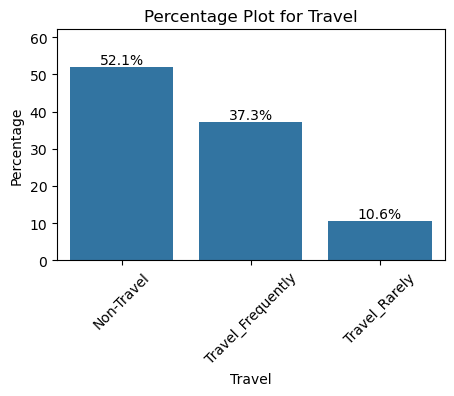

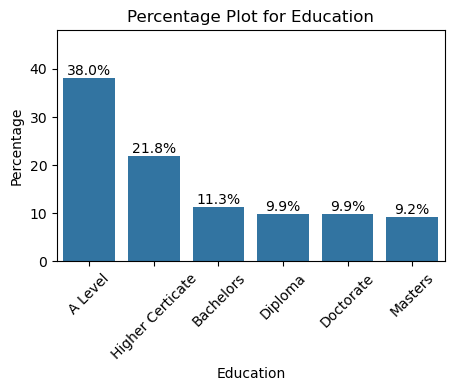

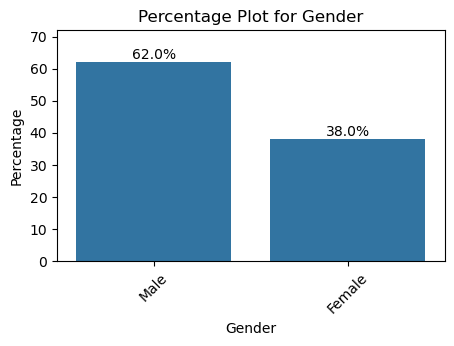

In [10]:
# Import necessary libraries for creating visualisations
import matplotlib.pyplot as plt
import seaborn as sns

# List of categorical columns
columns = ['Travel', 'Education', 'Gender']

# Function to calculate percentages and plot percentage bar charts
def plot_sns_percentage(survey, columns):
    for column in columns:
        # Calculate percentages
        percentages = survey[column].value_counts(normalize=True).mul(100).reset_index()
        percentages.columns = [column, 'percent']

        # Plot with adjusted y-axis limits and labels
        plt.figure(figsize=(5, 3))
        ax = sns.barplot(data=percentages, x=column, y='percent')
        plt.title(f"Percentage Plot for {column}")
        plt.ylabel('Percentage')
        plt.xticks(rotation=45)

        # Add percentage labels to bars
        for p in ax.patches:
            ax.annotate(f"{p.get_height():.1f}%", 
                        (p.get_x() + p.get_width() / 2., p.get_height()), 
                        ha='center', va='bottom', fontsize=10)

        plt.ylim(0, percentages['percent'].max() + 10)  # Add padding to y-axis
        plt.show()

# Plot the percentage bar charts using Seaborn
plot_sns_percentage(survey, columns)


>The majority of employees surveyed were male (62%) and more employees had either an A level education (38%) or Higher certificate (22%). Just over half (52%) did not travel while just over a third travelled frequently (37%).

### Continuous variables
Perform visualisation of the continuous variables to check for outliers, distibutions and relationships.

In [11]:
survey.columns

Index(['Rowid', 'Travel', 'Education', 'Gender', 'Age', 'Income', 'Tenure',
       'Satisfaction', 'Review'],
      dtype='object')

In [12]:
#drop the categorical variables and open-text variable and call new df survey_c
survey_c = survey.drop(['Rowid', 'Travel', 'Education', 'Gender', 'Review'],
                    axis=1)

# View new DataFrame.
print(survey_c.info())
survey_c.head()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 142 entries, 0 to 141
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Age           142 non-null    float64
 1   Income        142 non-null    float64
 2   Tenure        142 non-null    float64
 3   Satisfaction  142 non-null    float64
dtypes: float64(4)
memory usage: 4.6 KB
None


,Age,Income,Tenure,Satisfaction
0,50.0,6.60,22.0,32.0
1,32.0,1.57,0.0,64.0
2,19.0,2.40,1.0,68.0
3,20.0,2.07,1.0,61.0
4,55.0,15.97,27.0,100.0


#### Descriptive statistics

In [13]:
#provide descriptive statistics
survey_c.describe().round(3)

,Age,Income,Tenure,Satisfaction
count,142.000,142.000,142.000,142.000
mean,37.028,8.355,13.444,59.486
std,10.772,5.623,8.945,23.680
min,19.000,1.560,0.000,20.000
25%,27.000,4.070,6.250,37.000
50%,37.000,6.340,10.000,64.000
75%,45.750,14.350,20.750,73.000
max,58.000,20.240,36.000,100.000


> From the output, we can conclude:
>- All the columns have 142 values.
>- Age ranges between 19 years to 58 years with an average of 37 years
>- Monthly income ranges between 2,000 dollars per month to 14,000 dollars per month. The average is 8,000 per month.
>- The total years working (tenure) ranges between 0 years and 36 years with an average of 13 years.
>- Satisfaction scores range between 20 points to 100 points with an average of 59 points.
>
>  For k-means modelling we will scale the data as satisfaction scores has a much greater range than income and tenure. However, visualisations via boxplots/histograms/pairplots will be performed first.

#### Outliers
Boxplots will used to visualise whether there are any outliers.

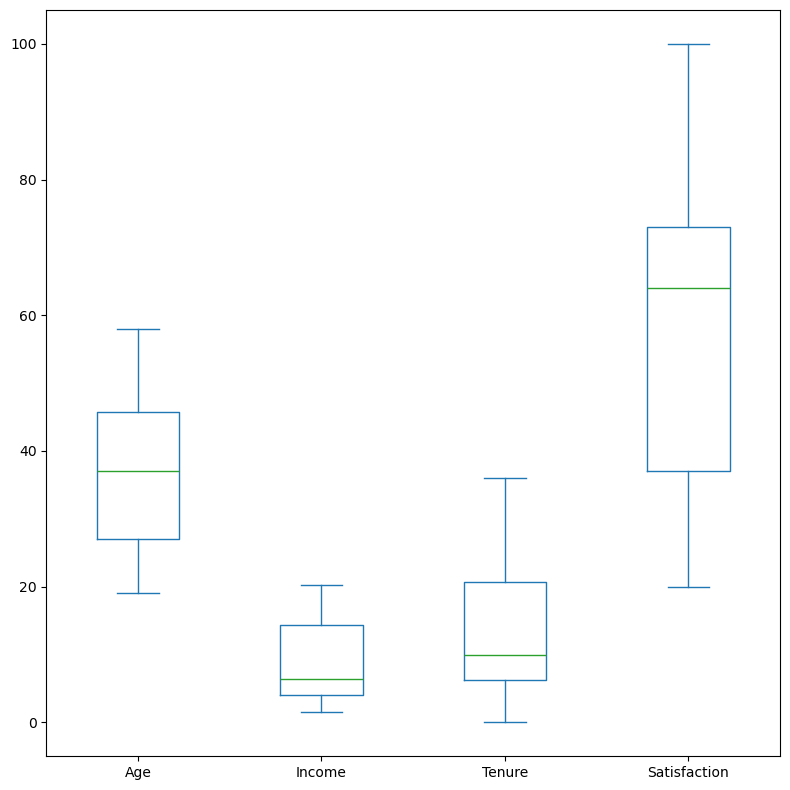

In [14]:
# Create a boxplots with Matplotlib (imported previously)

# Create the boxplot for each column in the DataFrame
survey_c.plot(kind='box', figsize=(8, 8))

# Show the plot
plt.tight_layout()
plt.show()


> The box plots of the continuous variables do not seem to indicate any outliers.

#### Distributions of continuous variables
Histograms will be used to visualise the distributions of the continuous variables.

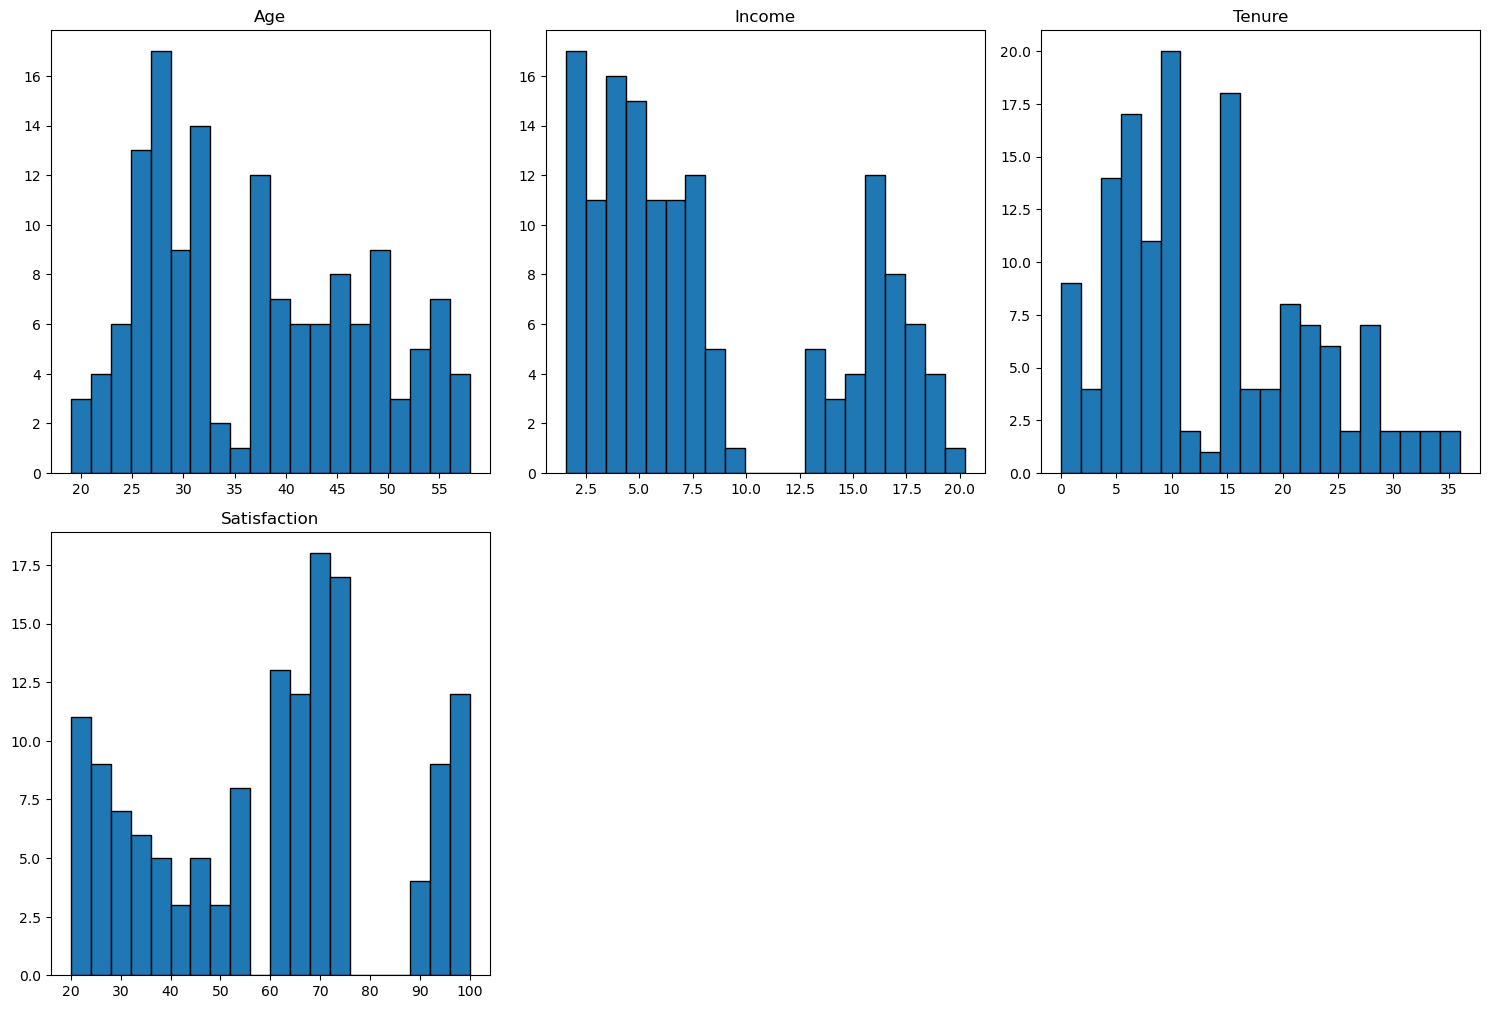

In [15]:
# Create the histograms for each column in the DataFrame
ax = survey_c.hist(figsize=(15, 20), bins=20, layout=(4, 3), edgecolor='black')

# Loop through each subplot to remove grid lines 
for subplot in ax.flatten(): 
    subplot.grid(False)

# Show the plot
plt.tight_layout()
plt.show()

> For age, there seems to be two peaks of normally distributed variables, cut off of 35 years.
> For income, there seems to be two peaks of normally distibuted variables, those below 10,000 per month and those above 12,000 per month.
> For tenure and satisfaction scores, there also seems to be two peaks (above and below 15 years for tenure and above and below 50 points for satisfaction).

#### Pairplots
Pairplots will be performed using seaborn (already imported above). To aid visualisation will use the categorical variables as the hue. However, as we are still in the exploration stage, will  conduct four pairplots, with hue either as 'Travel', 'Education', or 'Gender' and no hue.

In [16]:
survey.columns

Index(['Rowid', 'Travel', 'Education', 'Gender', 'Age', 'Income', 'Tenure',
       'Satisfaction', 'Review'],
      dtype='object')

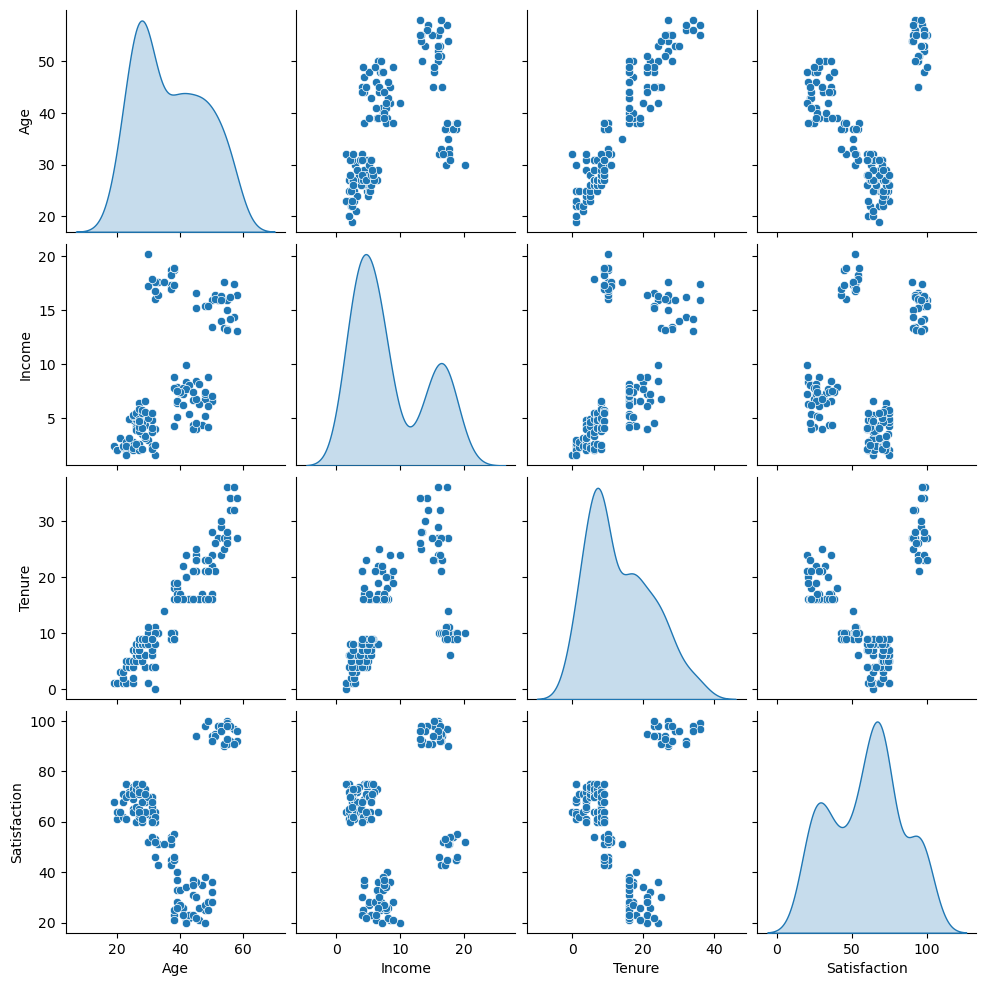

In [17]:
# Specify x variable.
X = survey[['Age', 'Income', 'Tenure', 'Satisfaction']]

# Create the pairplot.
sns.pairplot(survey, 
             vars=X,
             diag_kind='kde')

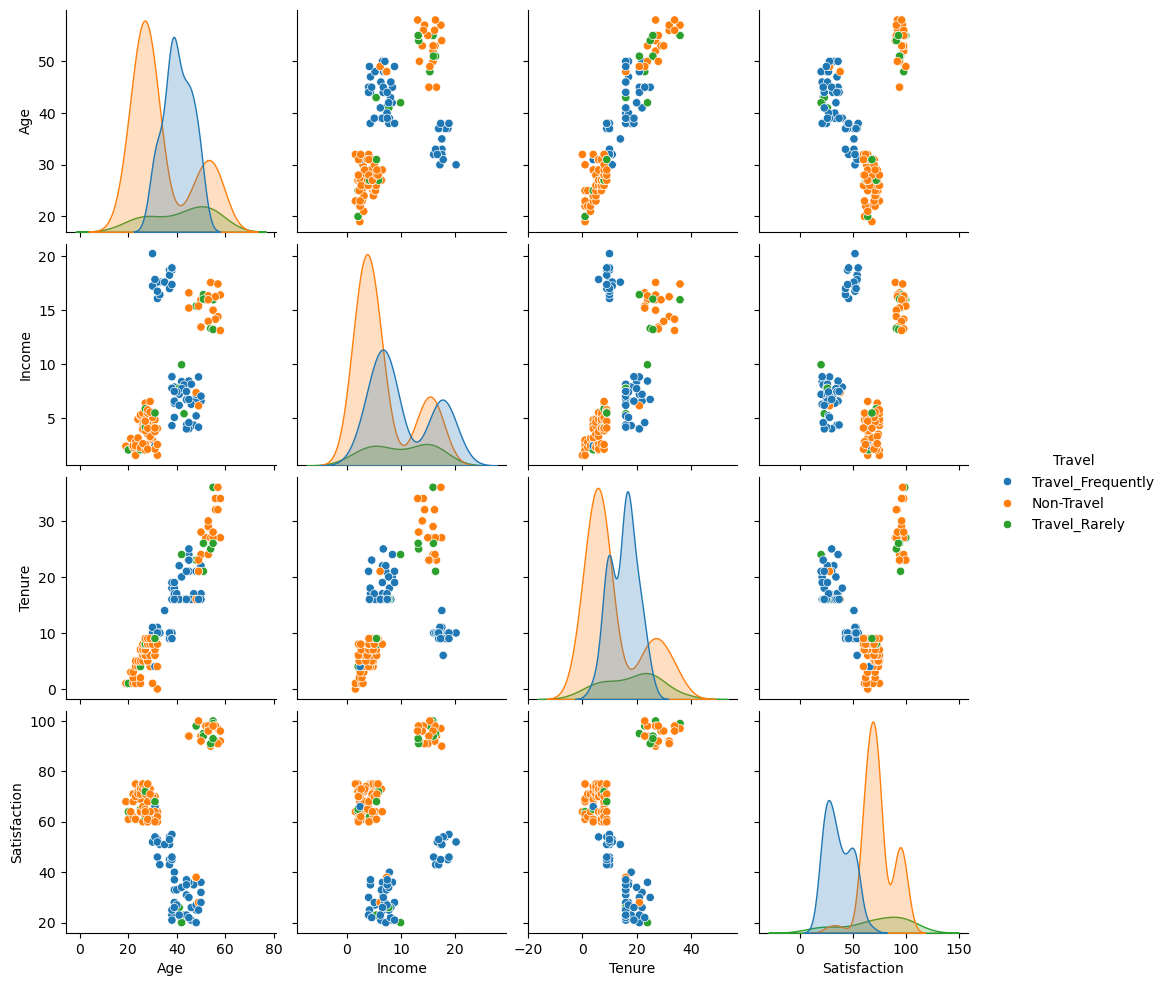

In [18]:
# Specify x variable.
X = survey[['Age', 'Income', 'Tenure', 'Satisfaction']]

# Create the pairplot.
sns.pairplot(survey, 
             vars=X,
             hue='Travel',
             diag_kind='kde')

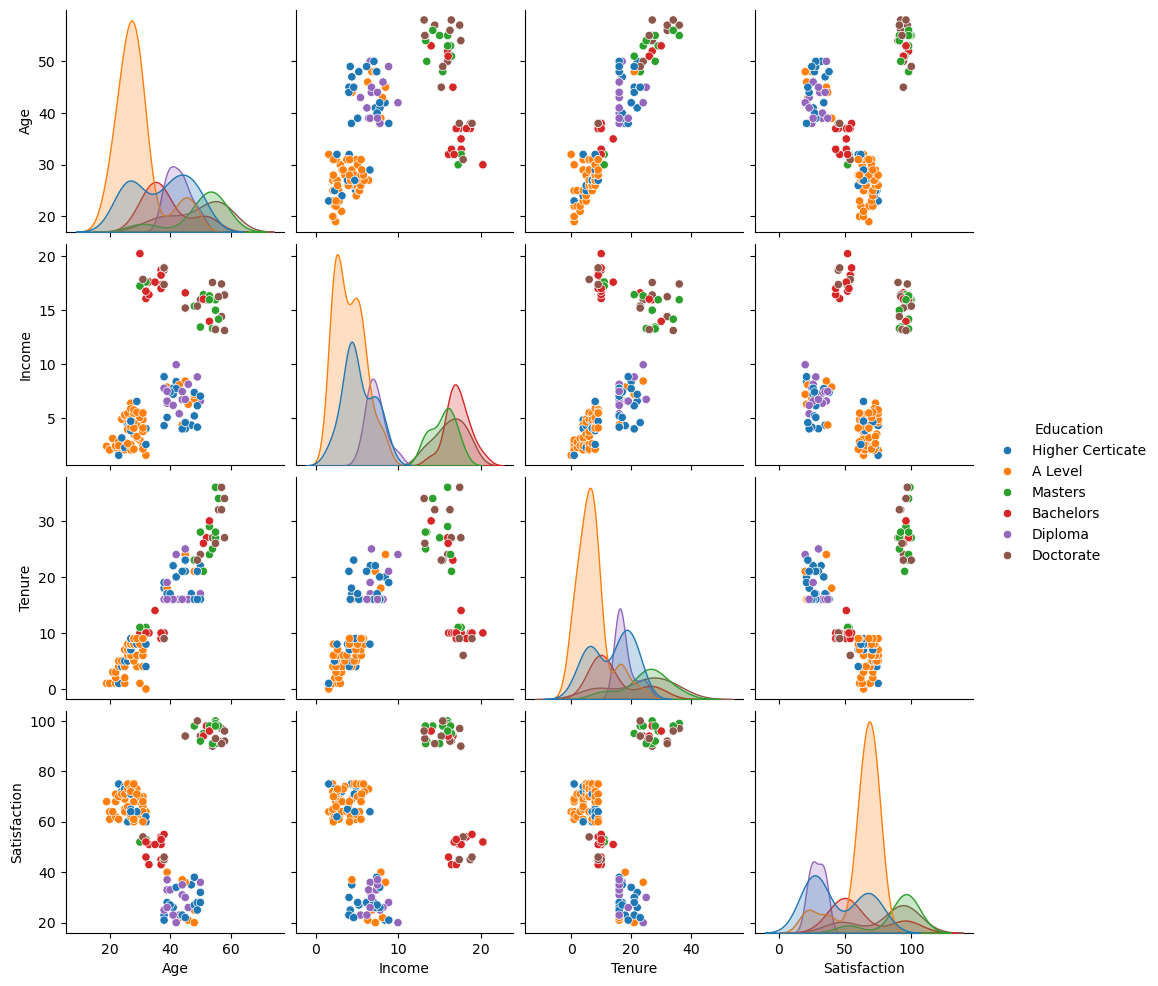

In [19]:
# Specify x variable.
X = survey[['Age', 'Income', 'Tenure', 'Satisfaction']]

# Create the pairplot.
sns.pairplot(survey, 
             vars=X,
             hue='Education',
             diag_kind='kde')

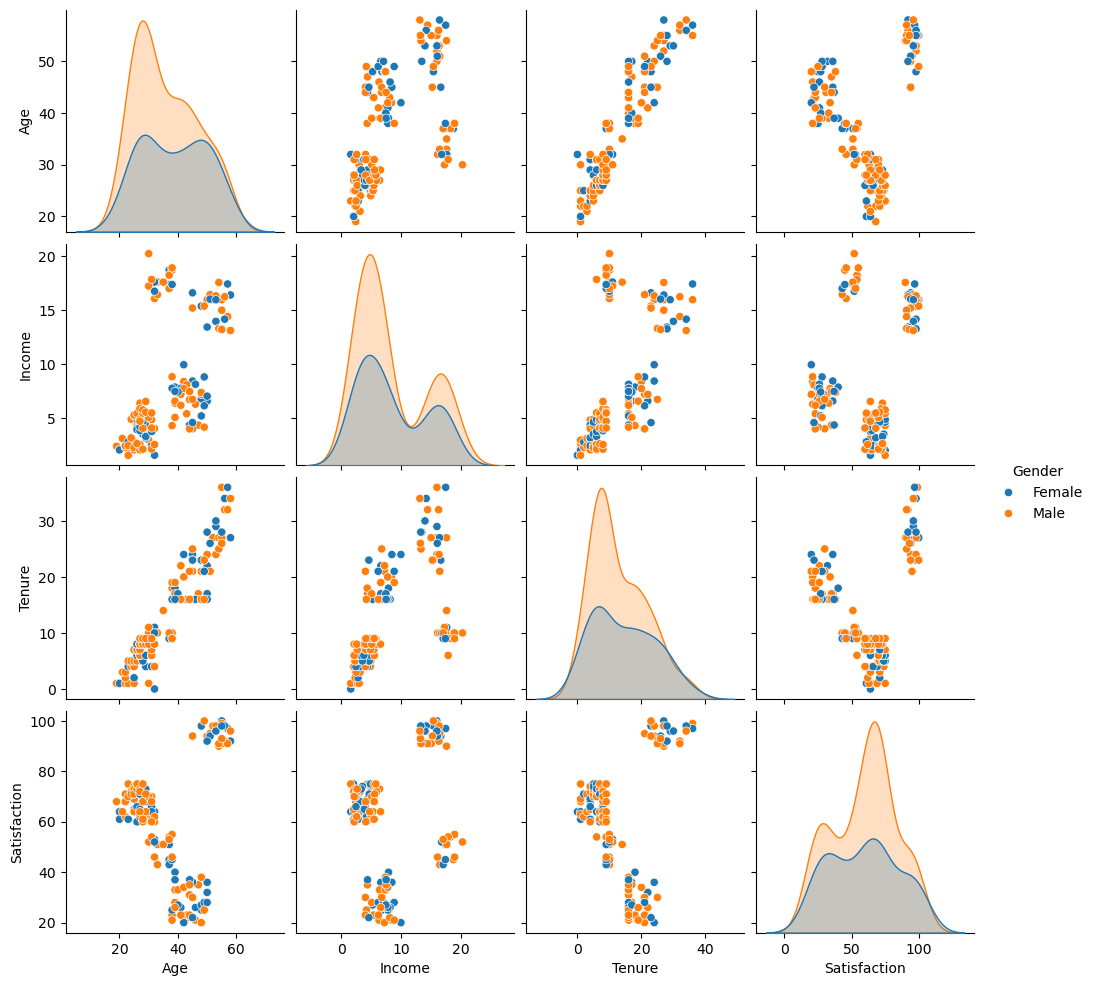

In [20]:
# Specify x variable.
X = survey[['Age', 'Income', 'Tenure', 'Satisfaction']]

# Create the pairplot.
sns.pairplot(survey, 
             vars=X,
             hue='Gender',
             diag_kind='kde')

> From the output of the pairplots we can conclude that:
>- All the variables, age, income, tenure and satisfaction follow a normal distribution. However as confirmed previously in the plots of the histograms, there are multiple peaks.
>- There seems to be no difference in the distributions or clusters for male or females, however there seems to be differences in the distributions or clusters when comparing education and travel.
>-	For income, there are two peaks and this was the same regardless of gender and travel frequency.  Each peak seems to correspond with education level with those in the lower income range had either A level, Higher Certificate or Diploma, while those in the upper income range had either Bachelors, Masters or Doctorate.
>-	For age and tenure there are two peaks for those that do not travel, whereas those that travel frequently or not at all had only one peak.
>-	There seems to be a linear relationship between tenure and age.
>-	Four clusters are shown when viewing the  satisfaction vs income chart with different distributions for education and travel.
>-  There seems to be two clusters for satisfaction vs age and for satisfaction vs tenure.

>For clarity, scatterplots of satisfaction and income for each catergory will be performed. 

### Scatter plot of Satisfaction and Income
Scatter plots between satisfaction and income to further clarify the four clusters.

<Axes: xlabel='Income', ylabel='Satisfaction'>

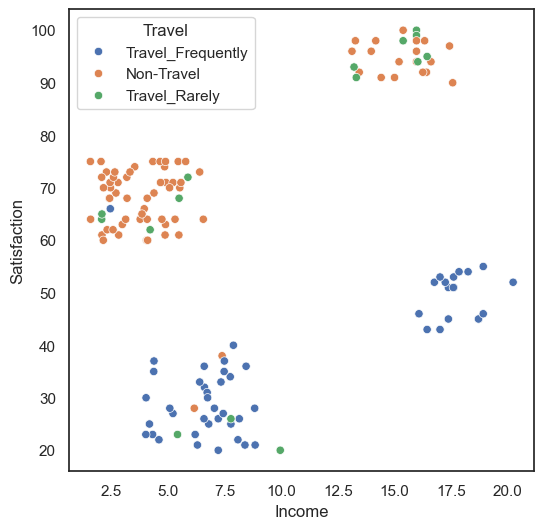

In [21]:
# Create a scatterplot with Seaborn (imported previously)
# Set plot size.
sns.set(rc = {'figure.figsize':(6, 6)})

# Set the style of the plot.
sns.set_style('white')

# Create scatterplot with hue = Travel
sns.scatterplot(x='Income',
                y='Satisfaction',
                data=survey,
                hue='Travel',
                )

>The top two clusters have more people who are non-travelers compared to the bottom two clusters who seem to travel frequently. Employees that travelled less frequently or not at all were more satisfied that those that travelled frequently, with this observation being the same whether in the lower or higher income bracket.

<Axes: xlabel='Income', ylabel='Satisfaction'>

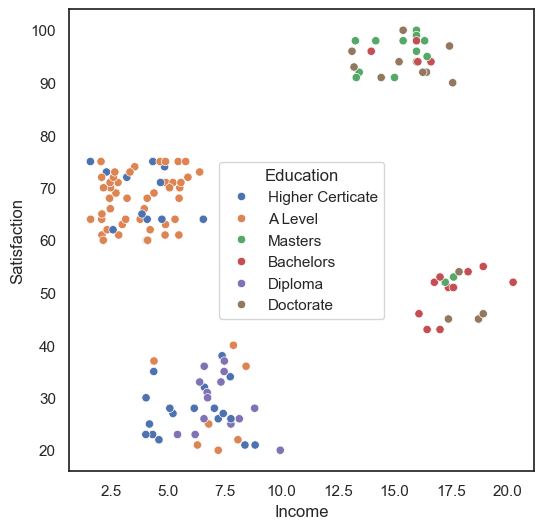

In [22]:
# Create scatterplot with hue = Education
sns.scatterplot(x='Income',
                y='Satisfaction',
                data=survey,
                hue='Education',
                )

>When comparing with education, the top right cluster is mainly Masters level or Doctorate, top left is mainly A level, bottom left is a mixture of mainly Higher Certificate or Diploma, while bottom right is mainly Bachelor. Even so, the separation of the clusters based on  Education are not as distinct as compared to Travel.

### Explore correlations between variables
Before exploring the correlations between variables to better understand the data, the categorical variables will be converted to numerical values.

In [23]:
#Convert categorical variables to explicitly defined numerical variables
# Define the mapping dictionaries
travel_map = {'Non-Travel': 1, 'Travel_Rarely': 2, 'Travel_Frequently': 3}
education_map = {
    'A Level': 1, 
    'Higher Certicate': 2, 
    'Diploma': 3, 
    'Bachelors': 4, 
    'Masters': 5, 
    'Doctorate': 6
}
gender_map = {'Female': 1, 'Male': 2}

# Apply the mappings to the DataFrame
survey['Travel'] = survey['Travel'].map(travel_map)
survey['Education'] = survey['Education'].map(education_map)
survey['Gender'] = survey['Gender'].map(gender_map)

# Verify the transformation
survey.head()

,Rowid,Travel,Education,Gender,Age,Income,Tenure,Satisfaction,Review
0,1,3,2,1,50.0,6.60,22.0,32.0,"Stuck with low wages for years, management doe..."
1,96,1,1,1,32.0,1.57,0.0,64.0,"ServiceFirst is a great start for my career, l..."
2,2,1,1,2,19.0,2.40,1.0,68.0,"I'm learning a ton here, love it!"
3,53,1,1,1,20.0,2.07,1.0,61.0,"ServiceFirst is a great start for my career, l..."
4,97,2,5,1,55.0,15.97,27.0,100.0,"I've been with ServiceFirst for over a decade,..."


> All categorical data has been converted to numerical

<Axes: >

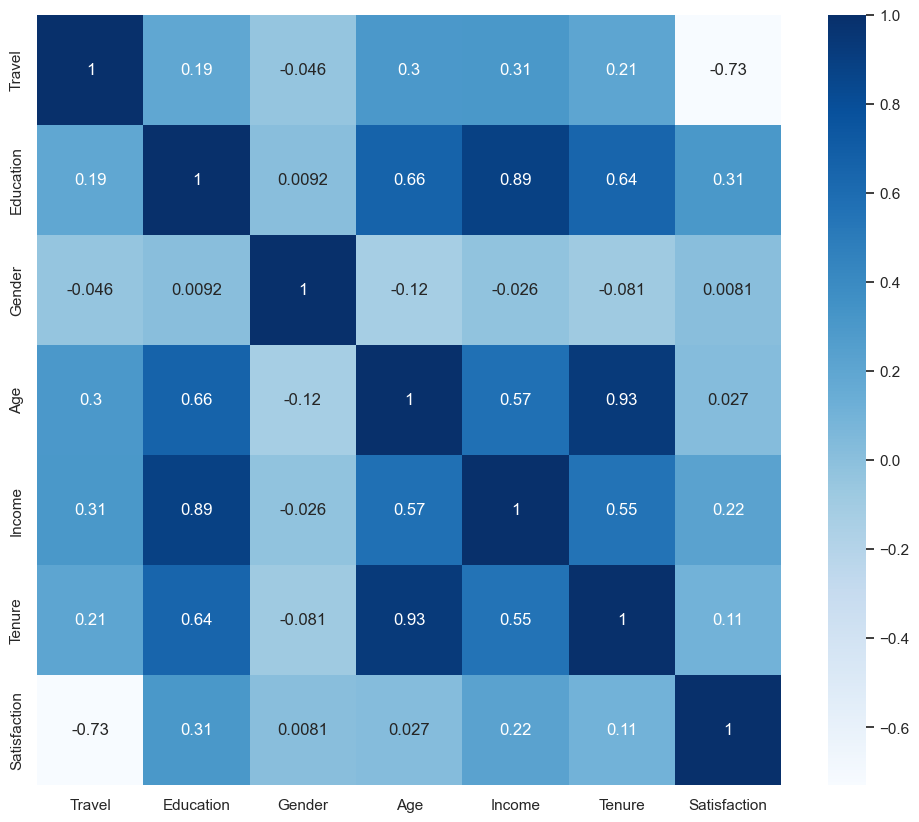

In [24]:
#visualise the correlations between the variables using the heatmap
#drop Rowid and Review variable
survey_r = survey.drop(['Rowid', 'Review'], axis=1)


# Set the size of the figure 
plt.figure(figsize=(12, 10 ))

# Check the correlation with a heatmap
sns.heatmap(survey_r.corr(),
            annot=True,
            cmap='Blues')

> Based on the outputs of the correlation coefficient (Pearson's r), we can conclude the following:
> - 'Satisfaction' has a very weak  to almost no linear correlation with the  variables 'age' ($r = 0.13$), 'income' ($r = 0.22$) and 'tenure' ($r = 0.11$). This confirms what was viewed in the pairplots.
> - There is a extremely strong positive correlation between 'Tenure' and 'Age' ($r = 0.93$), that is the higher the tenure, the higher the age.
> - There is a medium to substantial positive correlation between 'Income' and 'Age' ($r = 0.57$) and 'Income' and 'Tenure' ($r = 0.55$).
> Of the categorical variables:
> -  As expected being a non-ordinal catergorical variable there is no linear relationship between gender and any other variable.
> -  However, as travel and education are ordinal categorical variables, we are able to explore correlations with the continuous variables.
> -  Travel has a very weak positive linear relationship with education ($r = 0.19$).
> -  Travel has a weak to moderate positive linear relationship with tenure, income and age ($0.21\le r\le0.31$).
> -  There is a strong negative relationship between travel and satisfaction ($r = -0.73$). That is the more travel the employee has the lower the satisfaction score.
> -  Education has a weak to moderate positive relationship with satisfaction ($r = 0.31$). That is the higher the education, the higher the satisfaction
> -  Education has a medium to substantial positive relationship with tenure and age ($0.64\le r\le0.60$)
> -  Education has a very strong positive relationship with income ($r = 0.89$). That is the higher the education the higher the income.

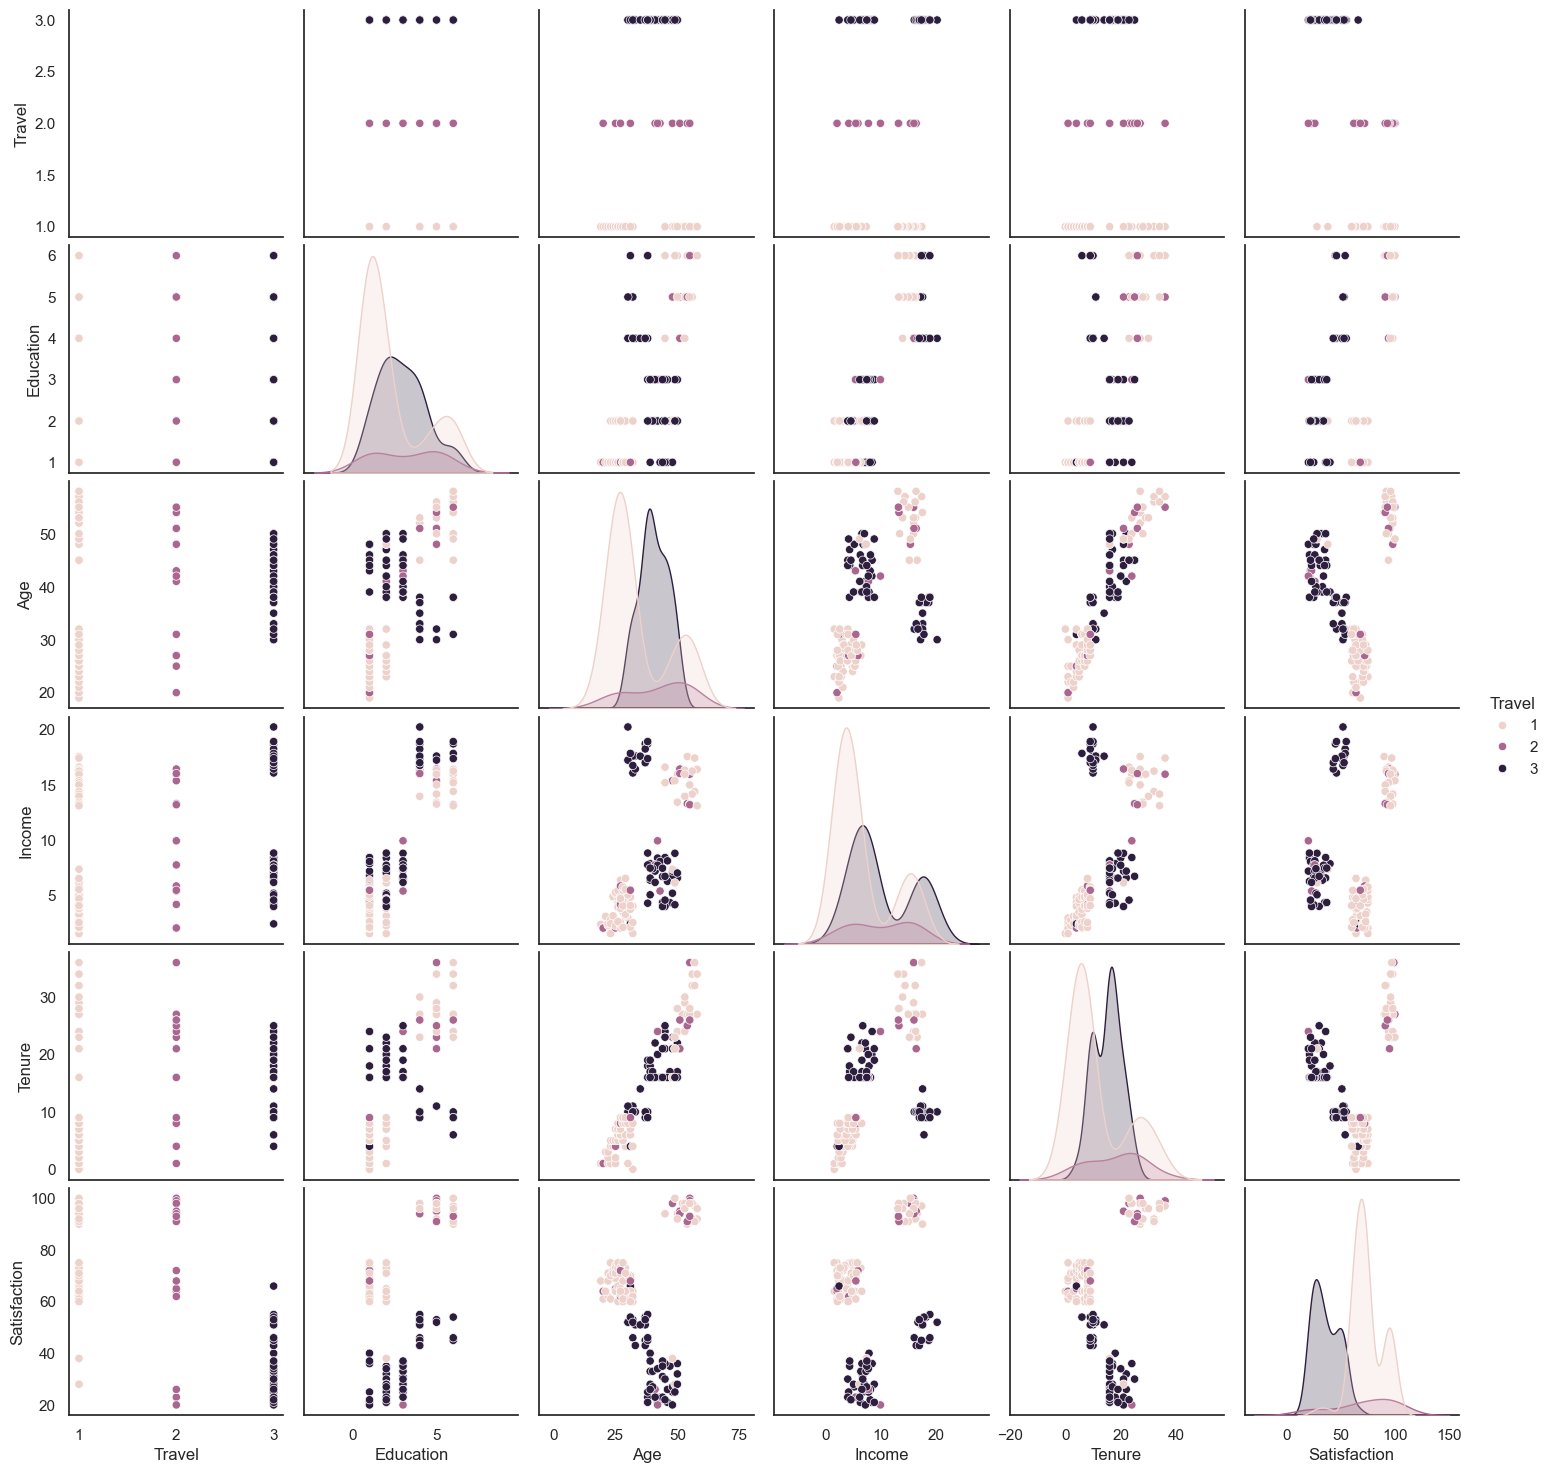

In [25]:
#Create pairplot to further view the relationships
# Specify x variable.
X = survey[['Travel', 'Education', 'Age', 'Income', 'Tenure', 'Satisfaction']]

# Create the pairplot.
sns.pairplot(survey, 
             vars=X,
             hue='Travel',
             diag_kind='kde')

Overall, from the exploration of the data, it indicates that there may be four clusters based on Income and Satisfaction scores, which seem to be mitigated by Education and amount of Travel. In turn, it was found that Income is also strongly positively related to Education levels. The scatterplots for Satisfaction and Age, as well as Satisfaction and Tenure, indicate the possibility of there may be three clusters instead of four.

# 4 Modelling and testing

## 4.1 K-means clustering
To address the first business goal:
- Identifying groups of employees with similar satisfaction levels and monthly incomes,

k-means clustering modelling will be utilised to group employees based on satisfaction levels and monthly income.

### a) Prediction
So far it is predicted from exploring the data that there are four clusters to explain the relationship between satisfaction scores and monthly income. However, the Elbow method and the Silhoutte method will be utilised to confirm the optimal number of clusters. 

### b) Standardise the data
Firstly the data will be standardardised as satisfaction scores have a much higher range than income, tenure and age. That way all the data will have a mean of 0 and a standard deviation of 1. Normalisation will not be required as the data was shown to be normally distributed.

In [26]:
#Conduct standardisation

#Import the library to conduct standardisation
from sklearn.preprocessing import StandardScaler

#Define X; X = features in survey (we will include age and tenure, to understand the data further)
features = ['Age', 'Income', 'Tenure', 'Satisfaction']
X = survey[features]

#Normalise the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

#Convert scaled data back to a DataFrame
X_scaled_df = pd.DataFrame(X_scaled, columns=features)

#view X_scaled_df
print(X_scaled_df.head())
print(X_scaled_df.describe().round(2))

        Age    Income    Tenure  Satisfaction
0  1.208524 -0.313176  0.959884     -1.164840
1 -0.468451 -1.210842 -1.508164      0.191305
2 -1.679599 -1.062719 -1.395980      0.360823
3 -1.586434 -1.121611 -1.395980      0.064166
4  1.674350  1.359016  1.520804      1.716968
          Age  Income  Tenure  Satisfaction
count  142.00  142.00  142.00        142.00
mean     0.00   -0.00    0.00          0.00
std      1.00    1.00    1.00          1.00
min     -1.68   -1.21   -1.51         -1.67
25%     -0.93   -0.76   -0.81         -0.95
50%     -0.00   -0.36   -0.39          0.19
75%      0.81    1.07    0.82          0.57
max      1.95    2.12    2.53          1.72


>From the output it can be confirmed that the data has been standardised with all variables having a mean of 0 and a standard deviation of 1.

### c) Find the optimal number of clusters using the Elbow Method and the Silhouette Method

#### Elbow method

Text(0, 0.5, 'Sum of squares')

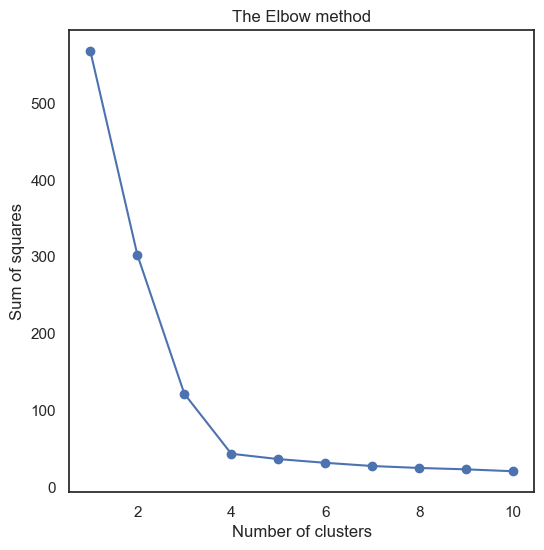

In [27]:
# Create Elbow chart for us to decide on the number of optimal clusters.
# Import the KMeans class.
from sklearn.cluster import KMeans 


# Default of max_iter=300 and n_init=10.
#Define X (note use the scaled dataframed)
X = X_scaled_df[['Age', 'Income', 'Tenure', 'Satisfaction']]

elbow = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i,
                    init='k-means++',
                    max_iter=300,
                    n_init=10,
                    random_state=0)
    kmeans.fit(X)
    elbow.append(kmeans.inertia_)

# Plot the elbow method.
plt.plot(range(1, 11),
         elbow,
         marker='o')

# Insert labels and title.
plt.title("The Elbow method")
plt.xlabel("Number of clusters")
plt.ylabel("Sum of squares")

> The within clusters sum of squared errors (SSE) decreases as the number of clusters (`k`) increase. The plot indicates the elbow occurs when 'k=4'. 

#### Silhouette method

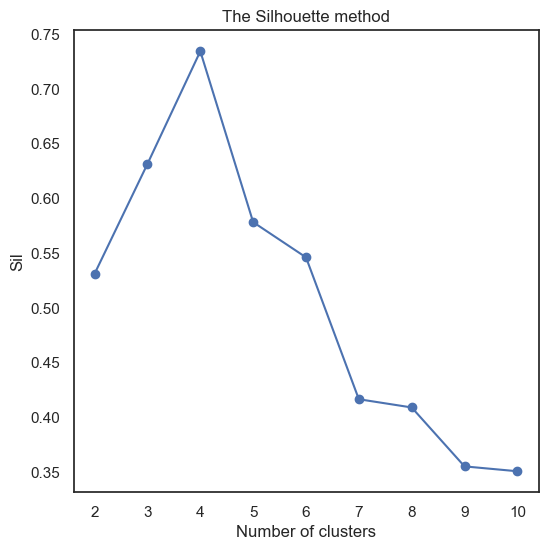

In [28]:
# Import silhouette_score class from sklearn.
from sklearn.metrics import silhouette_score

#X value already defined previously

# Find the range of clusters to be used with the silhouette method.
sil = []
kmax = 10


for k in range(2, kmax+1):
    kmeans_s = KMeans(n_clusters=k).fit(X)
    labels = kmeans_s.labels_
    sil.append(silhouette_score(X,
                                labels,
                                metric='euclidean'))

# Plot the silhouette method.
plt.plot(range(2, kmax+1),
         sil,
         marker='o')

# Insert labels and title.
plt.title("The Silhouette method")
plt.xlabel("Number of clusters")
plt.ylabel("Sil")

plt.show()

>The silhouette method measures cluster cohesion and separation. The silhouette coefficient values range between -1 and 1. Therefore, larger numbers indicate a better fit to a specific cluster (maximizing cohesion and separation). According to the chart, the average silhouette score (SIL) corresponds to a k-value of 4, with k=3 the next lowest, followed by k=5.
>
>
>From the Elbow method and Silhouette method, the optimal number of clusters is 4.
>
>However, we will evaluate the clusters for both k=3 and 4 based on our visualisations discussed previously.

### d) Evaluate and visualise clusters
The methods used to evaluate and visualise the clusters for either k=3 or k=4 will be as follows:

 - Produce visualisations via pairplots
 - Calculate the v-measure
 - Calculate and compare the means of the variables 'Satisfaction', 'Income', 'Age' and 'Tenure' for each cluster
 - Calculate and compare the number of values for the categorical values 'Travel' and 'Education'
 - Calculate and compare the cluster cardinality and magnitude for each cluster

#### Evaluation of clusters when k=4
Pairplots were used to visualise the clusterings.

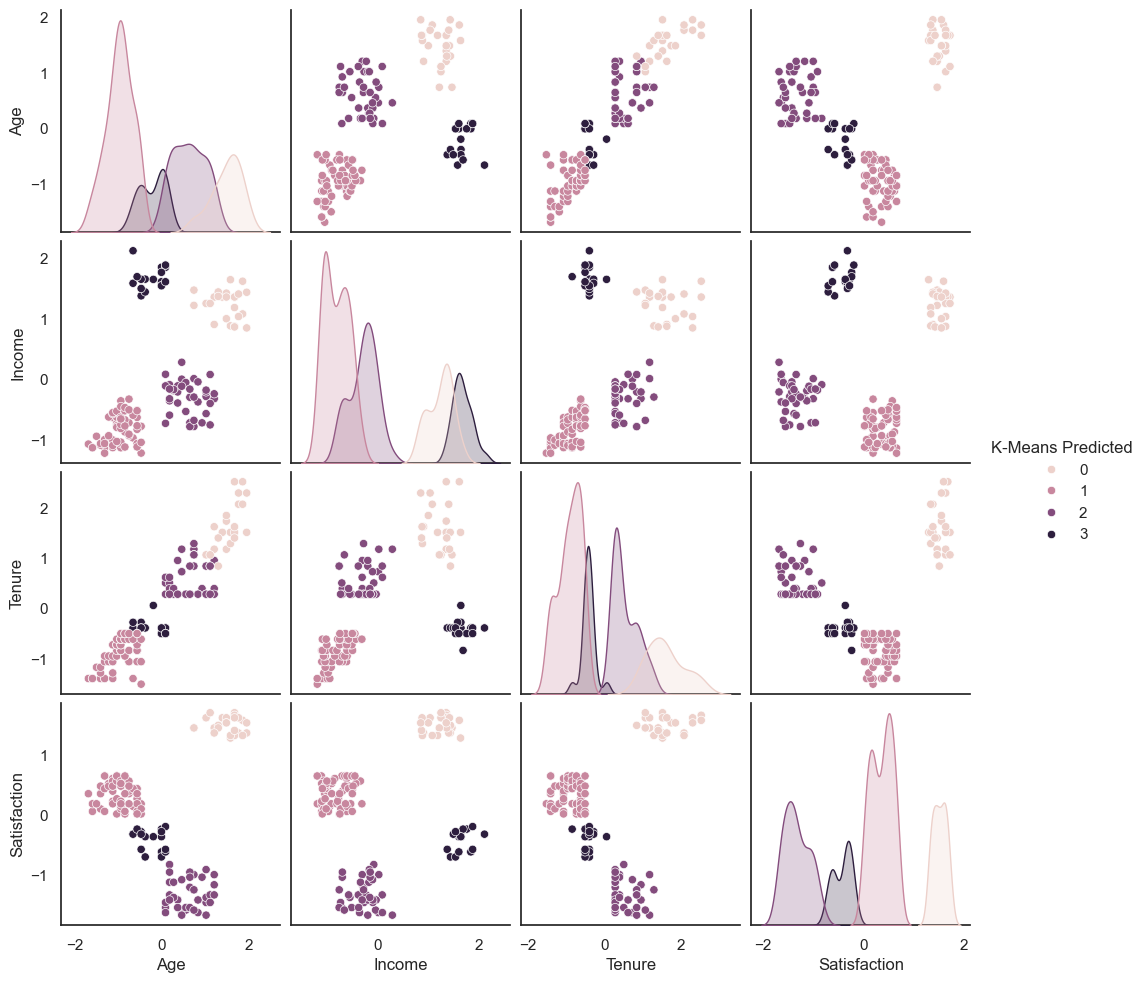

In [29]:
# Use four clusters.
kmeans = KMeans(n_clusters = 4, 
                max_iter = 300,
                init='k-means++',
                random_state=0).fit(X)

clusters = kmeans.labels_

X['K-Means Predicted'] = clusters

# Plot the predicted.
sns.pairplot(X,
             hue='K-Means Predicted',
             diag_kind='kde')

> Based on the pairplot, we can deduce the following:
>- The histograms indicate normally distributed data, with two peaks for cluster 1 and cluster 3 for distribution of Satisfaction scores.
>- Scatterplots indicate four clear clusters for `satisfaction` and `age`, `satisfaction` and `income`, `satisfaction` and `tenure` as well 'income' and 'tenure' and 'income' and 'age'. These clusters are hard clusters as there is no overlapping.

#### V-measure calculation
The V-measure measures the balance between homogeneity (how similar the elements within each cluster are) and completeness (how well all elements of a given true class are assigned to the same cluster). Its value ranges between 0 and 1, the closer to 1 the higher the agreement between the predicted clusters and the true labels. 

In [30]:
#import the v-measure calculation
from sklearn.metrics import v_measure_score

# Define the variables of the 'ground truth' labels - Education levels
true_labels = survey['Education']  
predicted_labels = X['K-Means Predicted']

# Calculate V-measure.
v_measure = v_measure_score(true_labels, predicted_labels)
print(f"V-Measure: {v_measure}")


V-Measure: 0.5706409204212135


>A v-measure of 0.57 indicates a moderate agreement between clusters and the true labels of education. The clustering captures some patterns that align with education.

In [31]:
# Define the variables of the 'ground truth' labels - Travel
true_labels = survey['Travel']  
predicted_labels = X['K-Means Predicted']

# Calculate V-measure.
v_measure = v_measure_score(true_labels, predicted_labels)
print(f"V-Measure: {v_measure}")


V-Measure: 0.4976664707044911


>A v-measure of 0.498 indicates some level of agreement between clusters and the true labels of Travel. However, this agreement is weaker compared to the V-measure for Education (0.57).

#### Compare means for 'Satisfaction', 'Income', 'Age' and 'Tenure' for each clusterfor each cluster group

In [32]:
# Add clusters to the original dataset.
survey['Cluster'] = X['K-Means Predicted']

# Calculate means for Satisfaction, Income, Age, and Tenure for each cluster.
cluster_means = survey.groupby('Cluster')[['Satisfaction', 'Income', 'Age', 'Tenure']].mean().round(2)

# Rename columns for clarity (optional).
cluster_means.columns = ['Satisfaction', 'Income', 'Age', 'Tenure']

# Print the combined table.
print(cluster_means)


         Satisfaction  Income    Age  Tenure
Cluster                                     
0               95.08   15.31  53.00   27.68
1               67.97    3.72  26.67    5.43
2               28.23    6.69  43.79   18.33
3               49.50   17.76  34.72    9.78


A line plot was created to better understand the output of the means.

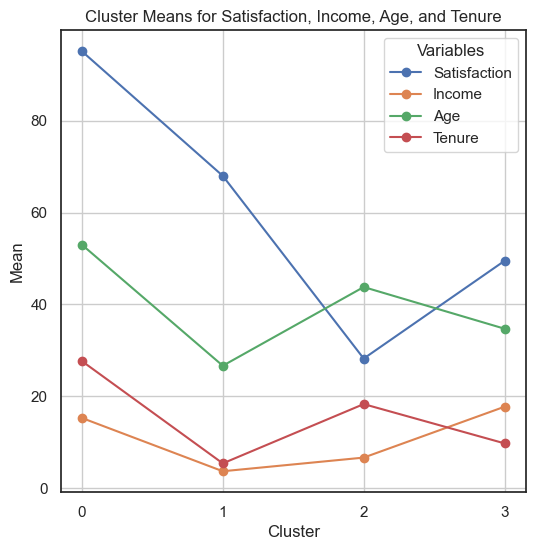

In [33]:
# Plot each variable across clusters
for column in cluster_means.columns:
    plt.plot(cluster_means.index, cluster_means[column], marker='o', label=column)

# Add titles, labels, legend, and grid
plt.title('Cluster Means for Satisfaction, Income, Age, and Tenure')
plt.xlabel('Cluster')
plt.ylabel('Mean')
plt.legend(title='Variables')
plt.xticks(ticks=cluster_means.index, labels=cluster_means.index)
plt.grid(True)

# Show the plot
plt.show()


>From the above output we notice that Satisfaction scores vary significantly among clusters, with Cluster 0 having the highest average Satisfaction (95.08) and Cluster 2 the lowest (28.23). Conversely, Cluster 0 also has a relatively low average Income (15.31), while Cluster 3, with a moderate Satisfaction score (49.50), has the highest Income (17.76). Thus there doesnt seem a clear pattern in the relationship between Satisfaction and Income levels. Other attributes like Age and Tenure also show variation but dont show a clear pattern with satisfaction scores. 

### Compare frequency for Travel and Education for each cluster

In [34]:
#create a cross tab to compare Education & Travel
# Add the original category columns, Travel and Eduction to the DataFrame
X_scaled_df[['Travel', 'Education']] = survey[['Travel', 'Education']]

#create a cross tab to compare Travel
comparison = pd.crosstab(X_scaled_df['Travel'], X['K-Means Predicted'] )
print(comparison)

#create a cross tab to compare Education
comparison = pd.crosstab(X_scaled_df['Education'], X['K-Means Predicted'] )
print(comparison)

K-Means Predicted   0   1   2   3
Travel                           
1                  18  54   2   0
2                   7   5   3   0
3                   0   1  34  18
K-Means Predicted   0   1   2   3
Education                        
1                   0  47   7   0
2                   0  13  18   0
3                   0   0  14   0
4                   4   0   0  12
5                  11   0   0   2
6                  10   0   0   4


>Note: FOr 'Travel' - 1=Non-Travel; 2=Travel_Rarely; 3=Travel_Frequently & For Education - 1=A Level; 2=Higher Certificate; 3=Diploma; 4=Bachelors; 5=Masters; 6=Doctorate 

>For Travel, Cluster 1 predominantly includes individuals who travel rarely, while Cluster 3 is mostly associated with frequent travelers. Non-travelers are more evenly distributed, with a notable presence in Clusters 0 and 1.

>For Education, Cluster 1 primarily consists of individuals with A-Level qualifications, while Cluster 2 displays a broader spread, including those with Higher Certificates and Diplomas. Cluster 3 is mostly associated with individuals holding Bachelors degrees, while Clusters 0 and 3 show higher representation among those with advanced qualifications like Masters and Doctorates. These patterns highlight how Travel and Education categories help distinguish the clusters.

### Cluster cardinality and magnitude
Cluster cardinality involves determining the number of data points in each cluster. If one cluster has significantlly high cardinality, it indicates the k-means clustering algorithm has over-generalised and grouped too many diverse data points together. A small cluster may indicate the presence of outliers.
Cluster magnitude measures the sum of distances from the centroid values to determine anomalies. Clusters with unusually high magnitudes might indicate anomalies. 
Note that clusters with higher cardinality will have higher magnitudes due to the increased number of points contributing to the sum. Plotting these two metrics together can reveal patterns or outliers. A scatterplot with a best-fit line helps identify deviations.

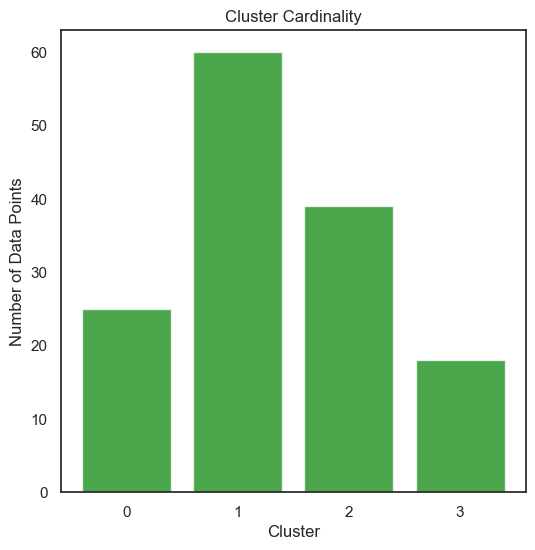

In [35]:
#import the function to calculate distance
from scipy.spatial.distance import cdist


# Calculate cluster cardinality.
cardinality = survey['Cluster'].value_counts().sort_index()

# Calculate distances from centroids for all points.
distances = cdist(X_scaled_df[['Age', 'Income', 'Tenure', 'Satisfaction']], 
                  kmeans.cluster_centers_, 
                  'euclidean')

# Calculate sum of distances (magnitude) for each cluster.
cluster_magnitude = [
    np.sum(distances[kmeans.labels_ == cluster, cluster])
    for cluster in range(kmeans.n_clusters)
]

# Combine cardinality and magnitude into a DataFrame for plotting.
cluster_analysis = pd.DataFrame({
    'Cluster': range(len(cardinality)),
    'Cardinality': cardinality.values,
    'Magnitude': cluster_magnitude
})

# Plot Cluster Cardinality (Bar Chart).
plt.bar(cluster_analysis['Cluster'], cluster_analysis['Cardinality'], color='green', alpha=0.7)
plt.xlabel('Cluster')
plt.ylabel('Number of Data Points')
plt.title('Cluster Cardinality')
plt.xticks(cardinality.index)  # Ensure x-axis ticks match cluster numbers.
plt.show()

>The bar chart indicates an uneven distribution of data points across clusters with Cluster 1 the largest and Cluster 3 the smallest.

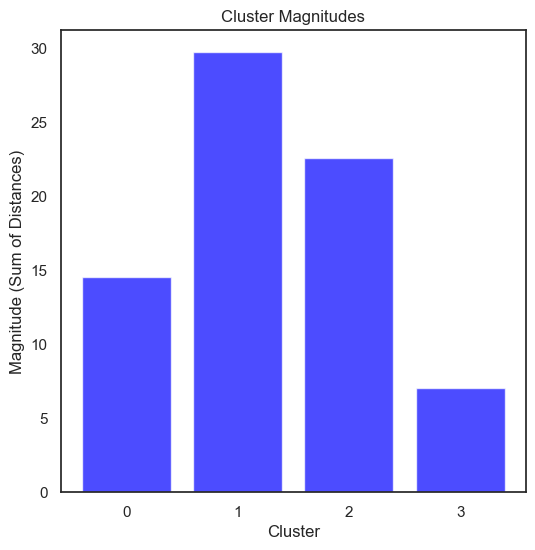

In [36]:
# Plot Cluster Magnitudes (Bar Chart).
plt.bar(cluster_analysis['Cluster'], cluster_analysis['Magnitude'], color='blue', alpha=0.7)
plt.xlabel('Cluster')
plt.ylabel('Magnitude (Sum of Distances)')
plt.title('Cluster Magnitudes')
plt.xticks(cardinality.index)  # Ensure x-axis ticks match cluster numbers.
plt.show()

>The bar chart shows that Cluster 1 has the highest magnitude (sum of distances from centroids) and Cluster 3 the lowest.

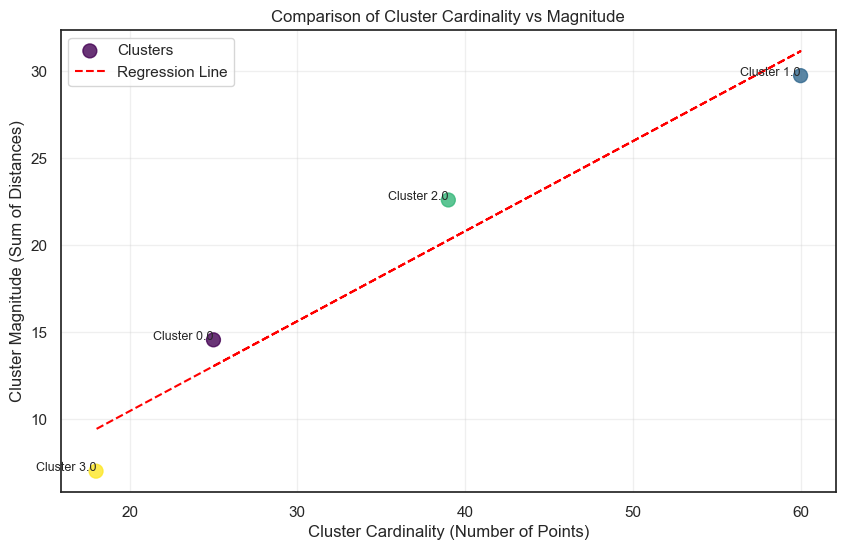

In [37]:
# Scatterplot for comparison of Cardinality vs Magnitude.
plt.figure(figsize=(10, 6))
plt.scatter(cluster_analysis['Cardinality'], cluster_analysis['Magnitude'], 
            c=cluster_analysis['Cluster'], cmap='viridis', s=100, alpha=0.8, label='Clusters')

# Add linear regression line.
# Fit the linear regression model.
slope, intercept = np.polyfit(cluster_analysis['Cardinality'], cluster_analysis['Magnitude'], 1)

# Calculate the regression line.
regression_line = slope * cluster_analysis['Cardinality'] + intercept

# Plot the regression line.
plt.plot(cluster_analysis['Cardinality'], regression_line, color='red', linestyle='--', label='Regression Line')

# Add labels to points in scatterplot.
for i, row in cluster_analysis.iterrows():
    plt.text(row['Cardinality'], row['Magnitude'], f"Cluster {row['Cluster']}", fontsize=9, ha='right')

# Add axis labels, title, legend, and grid.
plt.xlabel('Cluster Cardinality (Number of Points)')
plt.ylabel('Cluster Magnitude (Sum of Distances)')
plt.title('Comparison of Cluster Cardinality vs Magnitude')
plt.legend()
plt.grid(alpha=0.3)

# Show the scatterplot.
plt.show()

> The scatter plot indicates a positive relationship between cluster size (cardinality) and spread (magnitude). Larger clusters, like Cluster 1, are less compact, while smaller clusters, like Cluster 3, are tighter and more cohesive. Clusters above the regression line may lack compactness, suggesting opportunities to improve the clustering by balancing size and cohesion.

#### Evaluation of clusters when k=3
Pairplots were used to visualise the clusterings.

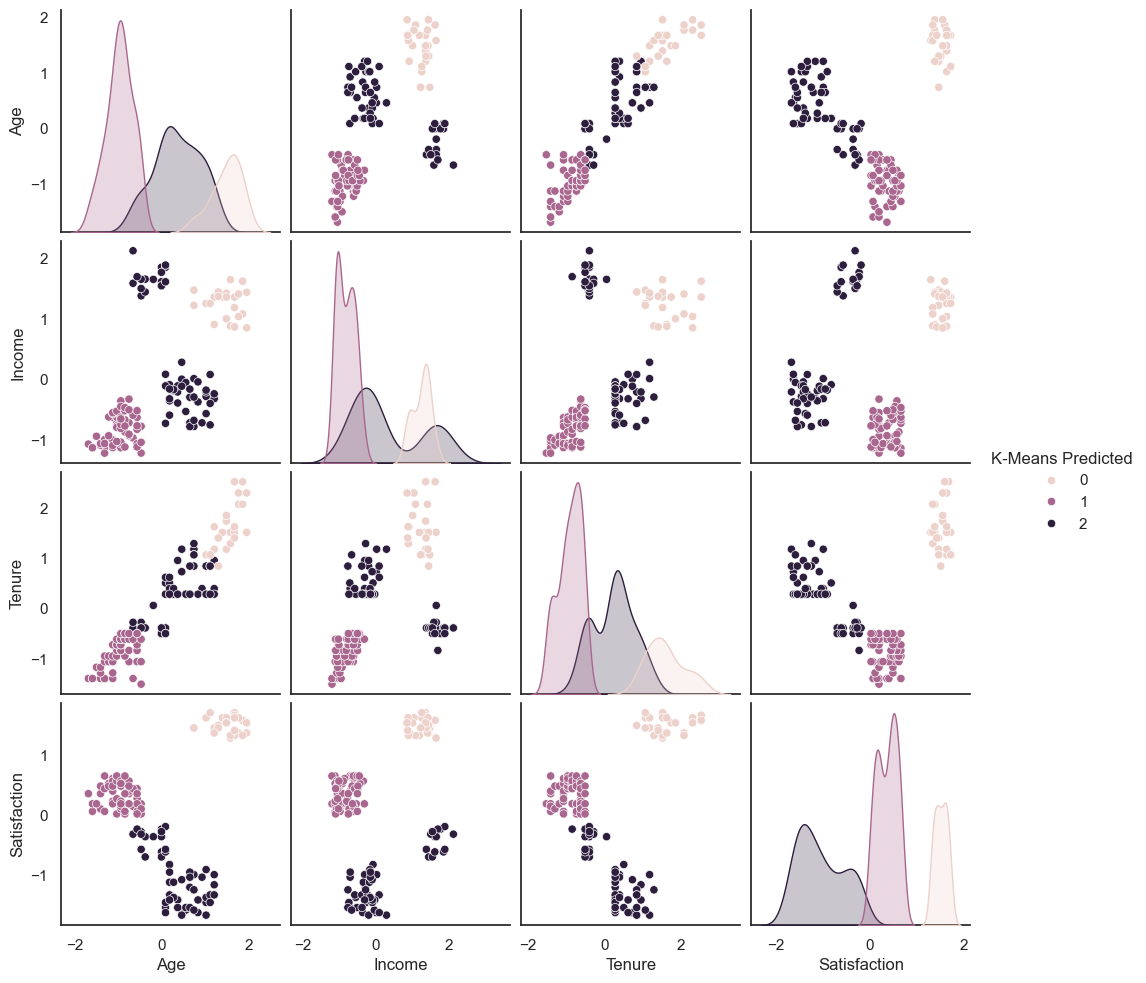

In [38]:
X = X_scaled_df[['Age', 'Income', 'Tenure', 'Satisfaction']]

# Use four clusters.
kmeans = KMeans(n_clusters = 3, 
                max_iter = 300,
                init='k-means++',
                random_state=0).fit(X)

clusters = kmeans.labels_

X['K-Means Predicted'] = clusters

# Plot the predicted.
sns.pairplot(X,
             hue='K-Means Predicted',
             diag_kind='kde')

>Compared to when k=4, the k=3 clustering seems to have combined clusters the 2 and 3 together. The clustering for Satisfaction vs Age and Satisfaction vs Tenure seems to be better for when k=3 compared to when k=4.

#### Evaluate clusters when k=3

#### V-measure calculation

In [39]:
#import the v-measure calculation
from sklearn.metrics import v_measure_score

# Define the variables of the 'ground truth' labels - Education levels
true_labels = survey['Education']  
predicted_labels = X['K-Means Predicted']

# Calculate V-measure.
v_measure = v_measure_score(true_labels, predicted_labels)
print(f"V-Measure: {v_measure}")


V-Measure: 0.43600939278866724


>Although there is some level of agreement, the v-measure for education is lower for k=3 then when k=4. 

In [40]:
# Define the variables of the 'ground truth' labels - Travel
true_labels = survey['Travel']  
predicted_labels = X['K-Means Predicted']

# Calculate V-measure.
v_measure = v_measure_score(true_labels, predicted_labels)
print(f"V-Measure: {v_measure}")

V-Measure: 0.546287042896364


>There is a moderate level of agreement between clusters and the true labels of Travel and this time it is stronger than for Education. It was also stronger than for when k=4.

#### Compare means for each cluster group

In [41]:
# Add clusters to the original dataset.
survey['Cluster'] = X['K-Means Predicted']

# Calculate means for Satisfaction, Income, Age, and Tenure for each cluster.
cluster_means = survey.groupby('Cluster')[['Satisfaction', 'Income', 'Age', 'Tenure']].mean().round(2)

# Rename columns for clarity (optional).
cluster_means.columns = ['Satisfaction', 'Income', 'Age', 'Tenure']

# Print the combined table.
print(cluster_means)

         Satisfaction  Income    Age  Tenure
Cluster                                     
0               95.08   15.31  53.00   27.68
1               67.97    3.72  26.67    5.43
2               34.95   10.19  40.93   15.63


A line plot was created to better understand the output of the means.

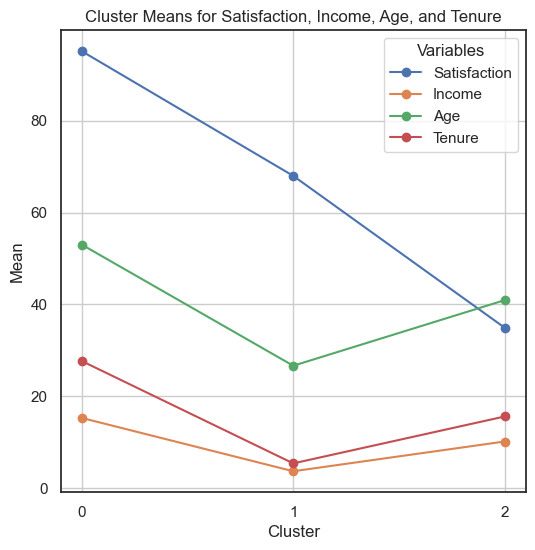

In [42]:
# Plot each variable across clusters
for column in cluster_means.columns:
    plt.plot(cluster_means.index, cluster_means[column], marker='o', label=column)

# Add titles, labels, legend, and grid
plt.title('Cluster Means for Satisfaction, Income, Age, and Tenure')
plt.xlabel('Cluster')
plt.ylabel('Mean')
plt.legend(title='Variables')
plt.grid(True)

# Set x-axis ticks to show only the main cluster points
plt.xticks(ticks=cluster_means.index, labels=cluster_means.index)

# Show the plot
plt.show()


>The outputs indicates a decline in Satisfaction scores as clusters transition from Cluster 0 to Cluster 2. The highest Satisfaction scores (Cluster 0) was associated with the highest Income, Age and Tenure. The middle Satisfaction Score (Cluster 1) was associated with the lowest Income, Age and Tenure, while the lowest Satisfaction score (Cluster 2) was associated with the middle Income, Age and Tenure means. The k=3 clustering highlights a more structured segmentation, with clear distinctions in Income, Satisfaction, Age, and Tenure suggesting that this configuration may better capture meaningful differences across the data.

### Compare frequency for Travel and Education

In [43]:
#create a cross tab to compare Education & Travel
# Add the original category columns, Travel and Eduction to the DataFrame
X_scaled_df[['Travel', 'Education']] = survey[['Travel', 'Education']]

#create a cross tab to compare Travel
comparison = pd.crosstab(X_scaled_df['Travel'], X['K-Means Predicted'] )
print(comparison)

#create a cross tab to compare Education
comparison = pd.crosstab(X_scaled_df['Education'], X['K-Means Predicted'] )
print(comparison)

K-Means Predicted   0   1   2
Travel                       
1                  18  54   2
2                   7   5   3
3                   0   1  52
K-Means Predicted   0   1   2
Education                    
1                   0  47   7
2                   0  13  18
3                   0   0  14
4                   4   0  12
5                  11   0   2
6                  10   0   4


>Note: For 'Travel' - 1=Non-Travel; 2=Travel_Rarely; 3=Travel_Frequently & For Education - 1=A Level; 2=Higher Certificate; 3=Diploma; 4=Bachelors; 5=Masters; 6=Doctorate
>
>Again for Travel, Cluster 0 and 1, predominantly includes individuals who travel rarely or not at all, while Clusters 2 is mostly associated with frequent travellers. 
For Education, Cluster 0 show higher representation among those with advanced qualifications like Masters and Doctorates. Cluster 2 primarily consists of individuals with A-Level qualifications and Higher Certificates. However, Cluster 3 seems to include all education levels which a greater representation of mid level education, Higher Certificates, Diplomas and Bachelor degrees. 


### Cluster cardinality and magnitude

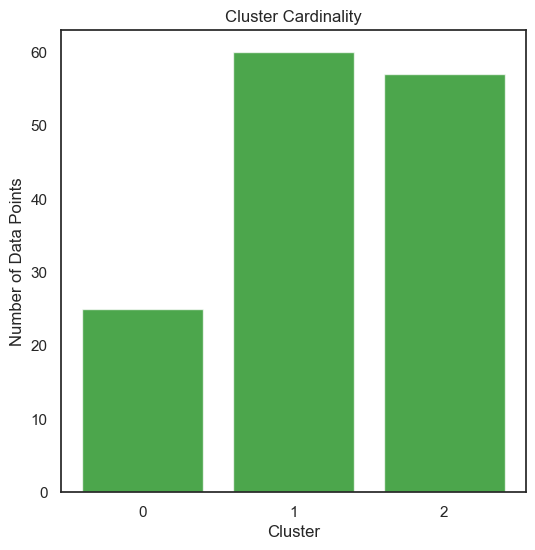

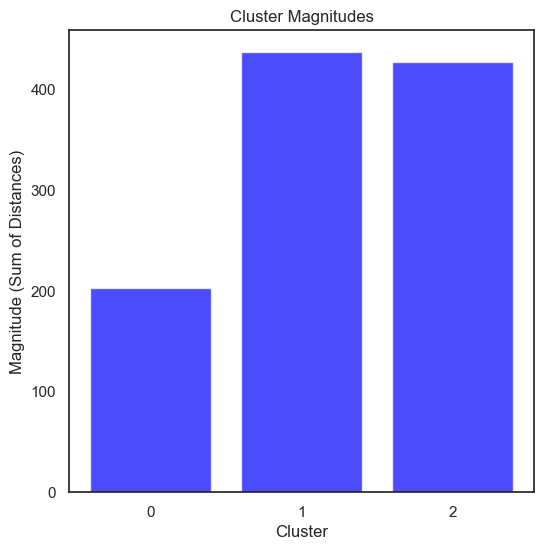

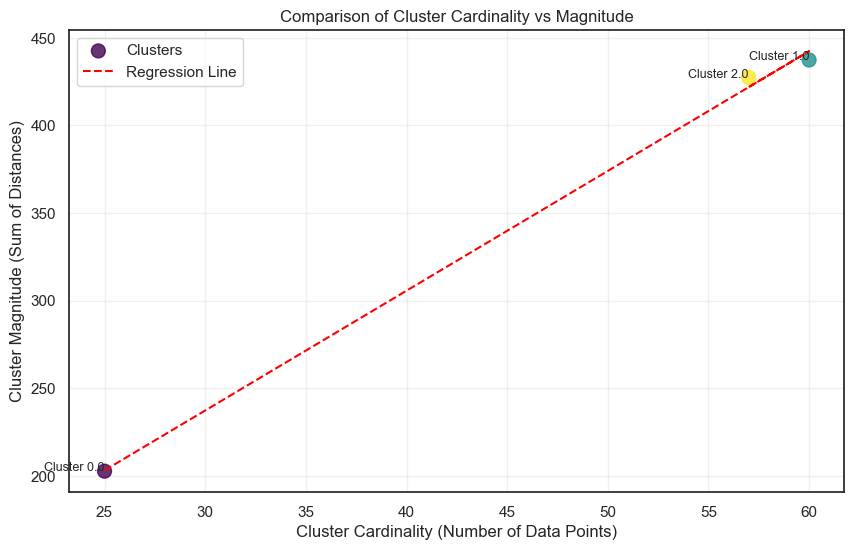

In [44]:
from scipy.spatial.distance import cdist

# Calculate cluster cardinality (number of points in each cluster).
cardinality = X['K-Means Predicted'].value_counts().sort_index()

# Calculate distances from centroids for all points.
distances = cdist(X_scaled_df[['Age', 'Income', 'Tenure', 'Satisfaction']], 
                  kmeans.cluster_centers_, 
                  'euclidean')

# Calculate sum of distances (magnitude) for each cluster.
cluster_magnitude = [
    np.sum(distances[np.where(kmeans.labels_ == cluster)]) for cluster in range(kmeans.n_clusters)
]

# Combine cardinality and magnitude into a DataFrame for plotting.
cluster_analysis = pd.DataFrame({
    'Cluster': range(len(cardinality)),
    'Cardinality': cardinality.values,
    'Magnitude': cluster_magnitude
})

# Plot Cluster Cardinality (Bar Chart).
plt.bar(cluster_analysis['Cluster'], cluster_analysis['Cardinality'], color='green', alpha=0.7)
plt.xlabel('Cluster')
plt.ylabel('Number of Data Points')
plt.title('Cluster Cardinality')
plt.xticks(cluster_analysis['Cluster'])
plt.show()

# Plot Cluster Magnitudes (Bar Chart).
plt.bar(cluster_analysis['Cluster'], cluster_analysis['Magnitude'], color='blue', alpha=0.7)
plt.xlabel('Cluster')
plt.ylabel('Magnitude (Sum of Distances)')
plt.title('Cluster Magnitudes')
plt.xticks(cluster_analysis['Cluster'])
plt.show()

# Scatterplot for comparison of Cardinality vs Magnitude.
plt.figure(figsize=(10, 6))
plt.scatter(cluster_analysis['Cardinality'], cluster_analysis['Magnitude'], 
            c=cluster_analysis['Cluster'], cmap='viridis', s=100, alpha=0.8, label='Clusters')

# Add linear regression line.
slope, intercept = np.polyfit(cluster_analysis['Cardinality'], cluster_analysis['Magnitude'], 1)
regression_line = slope * cluster_analysis['Cardinality'] + intercept
plt.plot(cluster_analysis['Cardinality'], regression_line, color='red', linestyle='--', label='Regression Line')

# Add labels to points in scatterplot.
for i, row in cluster_analysis.iterrows():
    plt.text(row['Cardinality'], row['Magnitude'], f"Cluster {row['Cluster']}", fontsize=9, ha='right')

# Add axis labels, title, legend, and grid.
plt.xlabel('Cluster Cardinality (Number of Data Points)')
plt.ylabel('Cluster Magnitude (Sum of Distances)')
plt.title('Comparison of Cluster Cardinality vs Magnitude')
plt.legend()
plt.grid(alpha=0.3)

# Show the scatterplot.
plt.show()


> Based on the evaluation, the choice between whether to have 3 or 4 clusters depends on the specific priorities for the clustering analysis.

>For k=4, the clustering creates four distinct, non-overlapping clusters in the pairplot, effectively segmenting the data into finer groups. The v-measures for Education (0.57) and Travel (0.498) suggest moderate alignment with true labels, with better agreement for Education compared to Travel. However, the clusters show an uneven distribution, with Cluster 1 being the largest and least compact, while Cluster 3 is the smallest and most cohesive. There is no clear pattern between Satisfaction and Income, and the clusters show some lack of compactness, indicating potential improvement opportunities.

> For k=3, the clustering merges two clusters from the k=4 scenario, resulting in a more structured segmentation. The pairplots show better clustering for Satisfaction vs. Age and Satisfaction vs. Tenure, and the outputs indicate a clearer decline in Satisfaction scores as clusters transition from Cluster 0 (highest satisfaction, income, age, and tenure) to Cluster 2 (lowest satisfaction but moderate income, age, and tenure). The v-measures show a tradeoff: Travel improves to 0.54, while Education declines to 0.44, suggesting a shift in alignment toward travel-related clustering. Additionally, the clusters are more balanced in size, with Clusters 1 and 2 being larger and less compact, while Cluster 0 is smaller and more cohesive.

> The k=3 clustering appears to offer more meaningful segmentation due to its clearer patterns, better-balanced cluster sizes, and well-defined relationships among Satisfaction, Income, Age, and Tenure. A notable insight from this clustering is the relationship between travel frequency and satisfaction. Employees who travelled most frequently were the least satisfied, while those who travelled rarely or not at all were significantly more satisfied. This pattern reveals distinct groups within the workforce.

>Please refer to final report, for futher discussion regarding the results of the clustering analysis.

## 4.2 Decision tree modelling
To address our second business goal:
- Creating a model to predict satisfaction levels based on various factors

we will build and evaluate a decision tree model to predict overall satisfaction scores based on various factors. 

### a) Prediction
Based on the exploration of the data as well as the k-means modelling, satisfaction levels may be predicted based on the following:
 - Travel frequency
 - Tenure and Age
 - Education level

Although Gender did not seem to have a relationship with Satisfaction levels, we will include in the initial classification modelling.

### b) Data preparation

#### Convert dependent variable (satisfaction level) from continuous variable to a categorical variable
Decision tree modelling classifies data into different categories or classes. Thus to use the decision model to predict satisfaction levels (dependent variable, i.e., y), we will need to convert it from a continuous variable to a categorical variable, as follows:

- Satisfied = Satisfaction scores >=50
- Dissatisfied = Satisfaction scores <50

In [45]:
#firstly drop the variables that will not be used in the decision modelling ie Rowid and Review 
#(and Cluster that was included in the k-means modelling)
survey_d = survey.drop(['Rowid','Review', 'Cluster'],
                    axis=1)


# Create a new column 'Satisfaction_overall'
survey_d['Satisfaction_overall'] = survey_d['Satisfaction'].apply(lambda x: 'Satisfied' if x >= 50 else 'Dissatisfied')

# Check the updated dataframe
survey_d.head(20)




,Travel,Education,Gender,Age,Income,Tenure,Satisfaction,Satisfaction_overall
0,3,2,1,50.0,6.60,22.0,32.0,Dissatisfied
1,1,1,1,32.0,1.57,0.0,64.0,Satisfied
2,1,1,2,19.0,2.40,1.0,68.0,Satisfied
3,1,1,1,20.0,2.07,1.0,61.0,Satisfied
4,2,5,1,55.0,15.97,27.0,100.0,Satisfied
5,3,4,2,33.0,17.62,10.0,51.0,Satisfied
6,2,1,1,20.0,2.06,1.0,64.0,Satisfied
7,1,1,2,22.0,2.41,1.0,68.0,Satisfied
8,1,1,1,23.0,2.03,1.0,75.0,Satisfied
9,3,3,1,50.0,6.59,17.0,36.0,Dissatisfied


> A new column 'Satisfaction_overall' has been created that corresponds with the values of the score for Satisfaction

In [46]:
print(survey_d.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 142 entries, 0 to 141
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Travel                142 non-null    int64  
 1   Education             142 non-null    int64  
 2   Gender                142 non-null    int64  
 3   Age                   142 non-null    float64
 4   Income                142 non-null    float64
 5   Tenure                142 non-null    float64
 6   Satisfaction          142 non-null    float64
 7   Satisfaction_overall  142 non-null    object 
dtypes: float64(4), int64(3), object(1)
memory usage: 9.0+ KB
None


### c) Conduct decision modelling
The decision modelling involves:
 - Setting the variable
 - Splitting the data into training (80%) and testing (20%)
 - Specifying and fitting the model
 - Visualising the model
 - Evaluating the model.


#### Set the variable for the decision model
The X and y will be specified where X (predictors) = Travel, Education, Gender, Age, Income, and Tenure and y (dependent variable) = Satisfaction_overall

In [47]:
# Define the variables.
X = survey_d.drop(['Satisfaction_overall', 'Satisfaction'],
            axis=1)

y = survey_d['Satisfaction_overall']

> There is no output or error message, indicating that Python is happy with the code snippet.

#### Split the data
The data will be split 80:20. This split leaves 80% of the data (around 114 observations) for training and 20% (around 28 observations) for testing. With a small dataset the 80:20 split can help ensure that the model has enough training data to conduct the classification modelling.

In [48]:
# Import train_test_split.
from sklearn.model_selection import train_test_split

# Split the data into training and testing sets.
X_train, X_test, y_train, y_test = train_test_split(X,
                                                    y,
                                                    test_size=0.2,
                                                    random_state=0)

>There is no output or error message, which indicates that Python is happy with the code snippet.

#### Specify and fit the model
We need to specify the decision tree model. Therefore, we'll use the DecisionTreeClassifier class from the sklearn.tree library. The criterian for the model will be gini. The Gini value represents the Gini impurity, which measures how "pure" or homogeneous a node is in terms of its classification. Gini ranges from 0 to 1, with the higher the value the more diversity at the node.

In [49]:
# Import the DecisionTreeClassifier.
from sklearn.tree import DecisionTreeClassifier

# Fit the model.
model = DecisionTreeClassifier(criterion='gini')

# Train the model.
model.fit(X_train, y_train)

DecisionTreeClassifier()

> The output `DecisionTreeClassifier` signifies that a decision tree model has been successfully generated using the values of `X` and `y`.

#### Test the model
Next, we'll determine the predicted values of `y` based on the `X_test` data set with the `predict()` method. 

In [50]:
# Predict on the test data set.
y_pred = model.predict(X_test)

# View output.
y_pred

array(['Dissatisfied', 'Satisfied', 'Dissatisfied', 'Dissatisfied',
       'Satisfied', 'Satisfied', 'Dissatisfied', 'Dissatisfied',
       'Dissatisfied', 'Satisfied', 'Satisfied', 'Satisfied', 'Satisfied',
       'Satisfied', 'Dissatisfied', 'Satisfied', 'Satisfied',
       'Dissatisfied', 'Satisfied', 'Satisfied', 'Dissatisfied',
       'Dissatisfied', 'Satisfied', 'Satisfied', 'Satisfied', 'Satisfied',
       'Satisfied', 'Satisfied', 'Satisfied'], dtype=object)

> An array was returned, indicating that the predicted values were generated. Next, we will visualise the decision tree model.

#### Visualise the model
The model will be visualised using the Textual tree and Graphviz tree as it is much easier to read and can be exported to a pdf file.

#### Textual tree

In [51]:
# To create a textual tree, need to import tree and export_text from sklearn
from sklearn import tree
from sklearn.tree import export_text

#create the text tree, which specifies actual column names
text_representation = export_text(model, feature_names=X.columns)

# View the text tree.
print(text_representation)

|--- Travel <= 2.50
|   |--- Age <= 36.50
|   |   |--- class: Satisfied
|   |--- Age >  36.50
|   |   |--- Income <= 11.53
|   |   |   |--- class: Dissatisfied
|   |   |--- Income >  11.53
|   |   |   |--- class: Satisfied
|--- Travel >  2.50
|   |--- Age <= 37.50
|   |   |--- Age <= 32.50
|   |   |   |--- class: Satisfied
|   |   |--- Age >  32.50
|   |   |   |--- Income <= 17.19
|   |   |   |   |--- class: Dissatisfied
|   |   |   |--- Income >  17.19
|   |   |   |   |--- Income <= 18.48
|   |   |   |   |   |--- class: Satisfied
|   |   |   |   |--- Income >  18.48
|   |   |   |   |   |--- class: Dissatisfied
|   |--- Age >  37.50
|   |   |--- Income <= 18.81
|   |   |   |--- class: Dissatisfied
|   |   |--- Income >  18.81
|   |   |   |--- Tenure <= 9.50
|   |   |   |   |--- class: Dissatisfied
|   |   |   |--- Tenure >  9.50
|   |   |   |   |--- class: Satisfied



#### Graphviz tree

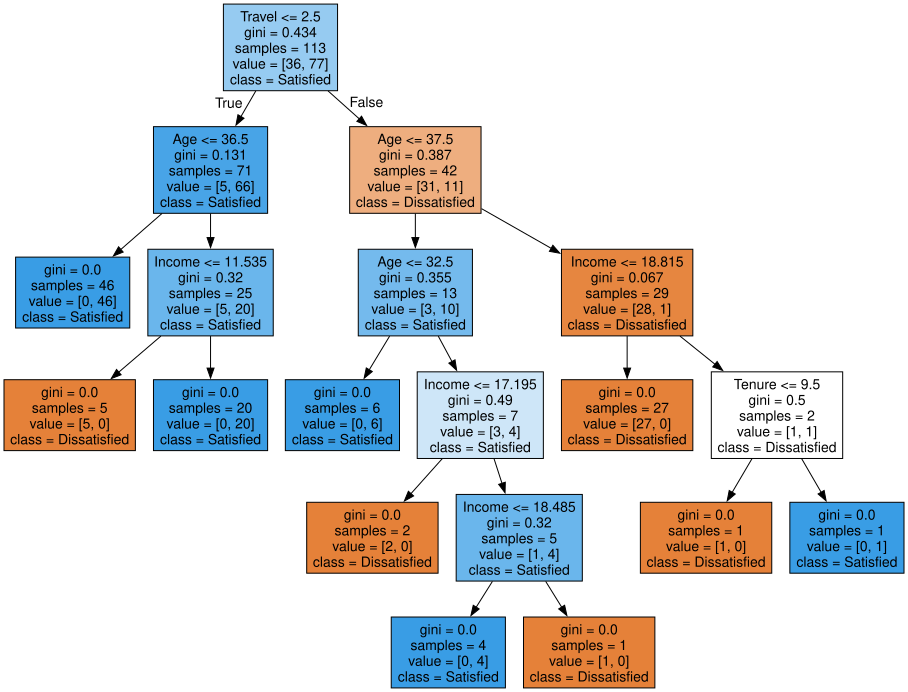

In [52]:
# Import graphviz and display
import graphviz
from sklearn.tree import export_graphviz  
from IPython.display import display

# Export the tree to a DOT file
export_graphviz(
    model,
    out_file="tree.dot",
    feature_names=X.columns,
    class_names=["Dissatisfied", "Satisfied"],
    filled=True
)

# Convert the DOT file to a PDF
graph = graphviz.Source.from_file("tree.dot")
graph.render("tree", format="pdf", cleanup=True)  # Exports to tree.pdf and cleans intermediate files

# Display the plot
display(graph)

> The output of the visuals indicates that the most important feature that predicts Satisfaction levels is Travel, the first split being those that travel frequently (Travel = 3, travel frequently) are dissatisfied compared to those that travel rarely or not at all  (Travel ≤ 2.5, i.e., no travel (1) and travel rarely (2)).
For those who travel frequently, the next predictor was Age then Education. For those who travel rarely or not at all the next predictor was Age, followed by Income thenEducatione
> Neither Tenure or Gender were predictors in the model.


### g) Evaluate the accuracy of a model
The accuracy of a model is evaluated by comparing its predictions to the actual values in the testing data set. The accuracy score, confusion matrix, and classification report from the sklearn library will be used to evaluate the model.

In [53]:
# Import accuracy_score, confusing_matrix, classification report from sklearn library
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Evaluate the model.
print("Accuracy:",
      accuracy_score(y_test, y_pred))

print("\nConfusion Matrix:\n",
      confusion_matrix(y_test, y_pred))

print("\nClassification Report:\n",
      classification_report(y_test, y_pred))

Accuracy: 0.9310344827586207

Confusion Matrix:
 [[ 9  1]
 [ 1 18]]

Classification Report:
               precision    recall  f1-score   support

Dissatisfied       0.90      0.90      0.90        10
   Satisfied       0.95      0.95      0.95        19

    accuracy                           0.93        29
   macro avg       0.92      0.92      0.92        29
weighted avg       0.93      0.93      0.93        29



>The evaluation output provides the following with regard to the predictors Travel, Age, Income and Education on satisfaction levels:
> - The model is 93.1% accurate overall in correctly prediciting those that are dissatistified and those that are satisfied
> - The model correctly predicted 9 cases as dissatisfied (True Negatives)
> - The model correctly predicted 18 cases as satisfied (True Positives)
> - One case was incorrectly predicted as satisfied (False Positive)
> - One case was incorrectly predicted as dissatisfied (False Negative)
> Precision:
> - Out of those that have been predicted as dissatisfied (9+1=10; TN+FN) the model correctly predicted 9 cases (90%)
> - Out of those that have been predicted as satisfied (18+1=19; TP+FP)  the model correctly predicted 18 cases (95%)
> Recall:
> - Out of all those that were actually dissatisfied (10) the model correctly predicted 9 cases (90%)
> - OUt of all those that were actually satisfied (19) the model correctly predicted 18 cases (95%)
> The F1 Score which combines Precision and Recall
> - The F1 score for dissatisfaction (0.9) is a little lower than for satisfaction (0.95), thus the model better at predicting those that are satisfied than those that are dissatisfied.
> - For ServiceFirst, they would more likely want to correctly identify those that are dissatisfied to ensure that can intervene appropriately with these employees to improve their job satisfaction and in turn more likely remain in the company. Therefore further modelling will be conducted to improve the decision tree model by pruning the tree to a maximum depth of 3 levels.

#### Pruning the decision model
As previously we will define the variables, split the data 80:20, fit the model using the criterian gini, and to a maximum depth of 3, the visualise and evaluate the model.

In [54]:
# Define the variables. X = Travel, Education, Gender, Age, Income and Tenure; y = Satisfaction_overall
X = survey_d.drop(['Satisfaction_overall', 'Satisfaction'],
            axis=1)

y = survey_d['Satisfaction_overall']

In [55]:
# Split the data into training and testing sets.
X_train, X_test, y_train, y_test = train_test_split(X,
                                                    y,
                                                    test_size=0.2,
                                                    random_state=0)

In [56]:
# Fit the model. but decrease the depth to 3 (ie prune the tree)
model = DecisionTreeClassifier(criterion='gini',
                               max_depth=3)

# Train the model.
model.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=3)

In [57]:
# Predict on the test data set.
y_pred = model.predict(X_test)

# View output.
y_pred

array(['Dissatisfied', 'Satisfied', 'Dissatisfied', 'Dissatisfied',
       'Satisfied', 'Satisfied', 'Dissatisfied', 'Dissatisfied',
       'Dissatisfied', 'Satisfied', 'Satisfied', 'Satisfied', 'Satisfied',
       'Satisfied', 'Satisfied', 'Satisfied', 'Satisfied', 'Dissatisfied',
       'Satisfied', 'Satisfied', 'Dissatisfied', 'Dissatisfied',
       'Satisfied', 'Satisfied', 'Satisfied', 'Satisfied', 'Satisfied',
       'Satisfied', 'Satisfied'], dtype=object)

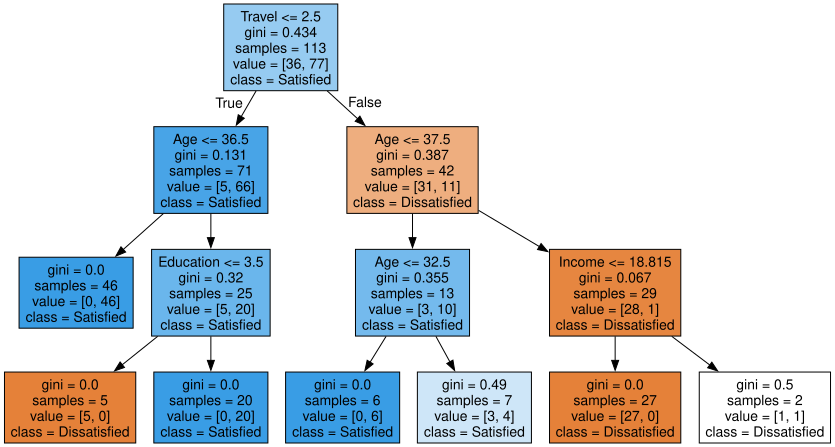

In [58]:
# Visulaise and export the tree to a DOT file
export_graphviz(
    model,
    out_file="tree1.dot",
    feature_names=X.columns,
    class_names=["Dissatisfied", "Satisfied"],
    filled=True
)

# Convert the DOT file to a PDF
graph = graphviz.Source.from_file("tree1.dot")
graph.render("tree1", format="pdf", cleanup=True)  # Exports to tree.pdf and cleans intermediate files

# Display the plot
display(graph)

> As shown in the output the most important feature that predicts Satisfaction remains the amount of travel. By pruning the true, Education is no longer a predictor. Instead, Tenure is a predictor for those who don’t travel or travel rarely (i.e. either Travel = 0 or 1), with Income as the next important factor. For employees who travel frequently (i.e., Travel = 3), Age emerged as the the next predictor, followed by Income.
> 
>Overall, the pruned decision tree indicates that out of those who travel infrequently or not at all, those with an income less than or equal to 11,535 dollars per month and a Tenure of less than or equal to 12.5 years were dissatisfied. This dissatisfaction, appears to be driven primarily by low income levels. It may also reflect a preference among some employees for roles involving travel, which are generally associated with higher remuneration.
> 
>For employees who travel frequently, dissatisfaction is associated with incomes of 18,815 dollars per month or less. This indicates that when travel is a significant aspect of a role, adequate compensation becomes crucial to reducing dissatisfaction. This finding suggests that ServiceFirst must ensure employees required to travel are remunerated appropriately, as insufficient compensation may exacerbate dissatisfaction with their role.

In [59]:
# Evaluate the model.
print("Accuracy:",
      accuracy_score(y_test, y_pred))

print("\nConfusion Matrix:\n",
      confusion_matrix(y_test, y_pred))

print("\nClassification Report:\n",
      classification_report(y_test, y_pred))

Accuracy: 0.9655172413793104

Confusion Matrix:
 [[ 9  1]
 [ 0 19]]

Classification Report:
               precision    recall  f1-score   support

Dissatisfied       1.00      0.90      0.95        10
   Satisfied       0.95      1.00      0.97        19

    accuracy                           0.97        29
   macro avg       0.97      0.95      0.96        29
weighted avg       0.97      0.97      0.97        29



> Even though Education Level is no longer a predictor, by pruning the true, the accuracy of the model has improved to 96.5%.
> The out put indicates the following:
> - The model correctly predicted 9 cases as dissatisfied (True Negatives)
> - The model correctly predicted 19 cases as satisfied (True Positive)
> - One case was incorrectly predicted as satisfied (False Positive)
> - No case was incorrectly predicted as dissatisfied (False Negative)
> Precision:
> - Out of those that have been predicted as dissatisfied (9+0=9) the model correctly predicted all cases (100%)
> - Out of those that have been predicted as satisfied (19+1=20) the model correctly predicted 19 cases (95%)
> Recall:
> - Out of all those that were actually dissatisfied (10) the model correctly predicted 9 cases (90%)
> - Out of all those that were actually satisfied (19) the model correctly predicted 19 cases (100%)
> The F1 Score which combines Precision and Recall
> - The F1 score for dissatisfaction (0.95) is a still a little lower than for satisfaction (0.97), however it has improved from the previous model which was 0.9.

## 4.3 Conduct sentiment analysis
To address our third business goal:
- Conduct a sentiment analysis of open-ended feedback

we will:
- Preprocess and tokenise employee feedback.
- Create visualisations and determine frequency distributions and
- Reviewing the polarity and sentiment of the feedback to identify the top positive and negative sentiments.
 

In [60]:
#review our original dataset again
print(survey.info())
survey.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 142 entries, 0 to 141
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Rowid         142 non-null    int64  
 1   Travel        142 non-null    int64  
 2   Education     142 non-null    int64  
 3   Gender        142 non-null    int64  
 4   Age           142 non-null    float64
 5   Income        142 non-null    float64
 6   Tenure        142 non-null    float64
 7   Satisfaction  142 non-null    float64
 8   Review        140 non-null    object 
 9   Cluster       142 non-null    int32  
dtypes: float64(4), int32(1), int64(4), object(1)
memory usage: 10.7+ KB
None


,Rowid,Travel,Education,Gender,Age,Income,Tenure,Satisfaction,Review,Cluster
0,1,3,2,1,50.0,6.60,22.0,32.0,"Stuck with low wages for years, management doe...",2
1,96,1,1,1,32.0,1.57,0.0,64.0,"ServiceFirst is a great start for my career, l...",1
2,2,1,1,2,19.0,2.40,1.0,68.0,"I'm learning a ton here, love it!",1
3,53,1,1,1,20.0,2.07,1.0,61.0,"ServiceFirst is a great start for my career, l...",1
4,97,2,5,1,55.0,15.97,27.0,100.0,"I've been with ServiceFirst for over a decade,...",0


>The original survey dataframe includes all the variables as well as the Cluster column included in our previous analysis for when k=3. The variable of interest to conduct the sentiment analysis is 'Review'.

### a) Prepare the data
To prepare this data set, the following steps will be performed:
- drop unnecessary columns
- remove missing values

In [61]:
#List the columns for ease of coding
survey.columns

Index(['Rowid', 'Travel', 'Education', 'Gender', 'Age', 'Income', 'Tenure',
       'Satisfaction', 'Review', 'Cluster'],
      dtype='object')

All the columns except Review column (includes the open-ended feedback) and Cluster column. The cluster column provides the k-means predicted grouping of 0, 1 & 2 (when k=3). We will use these grouping to compare the sentiment analysis in each of the groups.

In [62]:
#Drop all the columns except Review column (includes the open-ended feedback) and Cluster column
survey_s = survey.drop(['Rowid', 'Travel', 'Education', 'Gender', 'Age', 'Income', 'Tenure', 'Satisfaction'],
                       axis=1)

#view the df survey_s
print(survey_s.shape)
survey_s.head()

(142, 2)


,Review,Cluster
0,"Stuck with low wages for years, management doe...",2
1,"ServiceFirst is a great start for my career, l...",1
2,"I'm learning a ton here, love it!",1
3,"ServiceFirst is a great start for my career, l...",1
4,"I've been with ServiceFirst for over a decade,...",0


>survey_s dataframe now has two columns and 142 rows. If we recall previously we found that there were two missing rows of data in the Review column, that will need to be deleted.

#### Remove missing values

In [63]:
#Confirm missing values in dataframe
survey_s.isnull().sum()

Review     2
Cluster    0
dtype: int64

>It is confirmed that there are two missing rows of information in the Review column

In [64]:
#Remove the missing values
survey_s = survey_s.dropna()

# View DataFrame.
print(survey_s.shape)

#confirm missing values removed
survey_s.isnull().sum()

(140, 2)


Review     0
Cluster    0
dtype: int64

>Two rows have been dropped and so there are no longer any missing values

### b) Preprocess the data
The data will be preprocessed to ensure the feedback is in the same format for ease of analysis and comparison.
The following preprocessing actions will be conducted

 - ensure data is in string format
 - change all the words to lowercase
 - expand any contractions
 - remove punctuations
 - remove duplicates

#### Ensure data is in string format
Most of the coding for NLP requires that the data is in string format

In [65]:
#Check datatype
review_dtype = survey_s['Review'].dtype
print(review_dtype)

object


>data is in object format so it will be converted to string

In [66]:
# Convert the 'Review' column to string type
survey_s['Review']= survey_s['Review'].astype('string')

review_dtype = survey_s['Review'].dtype
print(review_dtype)

string


In [67]:
# Verify the first few types of elements in the 'Review' column
print(type(survey_s['Review'].iloc[0]))

<class 'str'>


>data is in string format

#### Change all words in Review column to lower case

In [68]:
# Transform data to lower case.
survey_s['Review'] = survey_s['Review'].apply(lambda x: " ".join(x.lower() for x in x.split()))

# Expand the column width to display the full statement.
pd.set_option('display.max_colwidth', None)

# Preview the result.
survey_s['Review'].head(20)

0                                                                        stuck with low wages for years, management doesn’t seem to care
1                                                                           servicefirst is a great start for my career, learning a lot!
2                                                                                                      i'm learning a ton here, love it!
3                                                                            servicefirst is a great start for my career, learning a lot
4     i've been with servicefirst for over a decade, and the ability to work from home has been a game-changer for my work-life balance.
5                                                                 i feel like i never see my kids because i'm always traveling for work.
6                                                                                        pay's not high, but the experience is worth it.
7                                        

>The comments are now all in lower case.

#### Expand contractions
Contractions such as 'I'm', haven't, will be expanded to retain the semantic meaning of the words

In [69]:
#import contractions library
import contractions

# Expand contractions in the Review column
survey_s['Review'] = survey_s['Review'].apply(lambda x: contractions.fix(x) if isinstance(x, str) else x)

# View the updated DataFrame
survey_s['Review'].head(20)

0                                                                         stuck with low wages for years, management does not seem to care
1                                                                             servicefirst is a great start for my career, learning a lot!
2                                                                                                       i am learning a ton here, love it!
3                                                                              servicefirst is a great start for my career, learning a lot
4     i have been with servicefirst for over a decade, and the ability to work from home has been a game-changer for my work-life balance.
5                                                                  i feel like i never see my kids because i am always traveling for work.
6                                                                                          pay's not high, but the experience is worth it.
7                          

> The output shows that contracted such as i'm and i'have have been expanded.

#### Remove punctuation
To standardise the data and simplify the comparison , punctuations will be removed.

In [70]:
# Remove punctuation.
survey_s['Review'] = survey_s['Review'].str.replace('[^\w\s]', '' , regex=True)

# Preview the result.
survey_s['Review'].head(20)

0                                                                      stuck with low wages for years management does not seem to care
1                                                                           servicefirst is a great start for my career learning a lot
2                                                                                                     i am learning a ton here love it
3                                                                           servicefirst is a great start for my career learning a lot
4     i have been with servicefirst for over a decade and the ability to work from home has been a gamechanger for my worklife balance
5                                                               i feel like i never see my kids because i am always traveling for work
6                                                                                         pays not high but the experience is worth it
7                                                      

>All punctuations have been removed.

### Remove duplicate values

In [71]:
#check for duplicate values in the Review column
survey_s.Review.duplicated().sum()

10

>Interesting that we found 10 duplicate values, although when we viewed the whole dataframe survey there were no duplicate rows. 

In [72]:
#view the duplicates
survey_s[survey_s.Review.duplicated()]

,Review,Cluster
3,servicefirst is a great start for my career learning a lot,1
56,no comment,2
60,it is good,1
77,love sf,0
79,no comment,1
109,love servicefirst,1
112,servicefirst is a good place to start,1
124,no comment,1
133,it is okay,2
139,it is okay,2


>Although there are duplicates in the Review column, most of the actual comments ('no comment', 'It is okay' and 'love sf'), are common phrases. However, the phrase 'servicefirst is a good place to start' and 'servicefirst is a great start for my career learning a lot' is too unique, so only the duplicates of these statements will be removed.

In [73]:
#drop the row with index = 112 & 3 in the survey_s df
survey_s = survey_s.drop(index=[112, 3]).reset_index(drop=True)

#confirm that it has been removed
survey_s[survey_s.Review.duplicated()]

,Review,Cluster
54,no comment,2
58,it is good,1
75,love sf,0
77,no comment,1
106,love servicefirst,1
120,no comment,1
129,it is okay,2
135,it is okay,2


> The output confirms that the duplicate rows have been removed.

In [74]:
#view the final dataframe
print(survey_s.shape)
print(survey_s.head(20))

(138, 2)
                                                                                                                              Review  \
0                                                                    stuck with low wages for years management does not seem to care   
1                                                                         servicefirst is a great start for my career learning a lot   
2                                                                                                   i am learning a ton here love it   
3   i have been with servicefirst for over a decade and the ability to work from home has been a gamechanger for my worklife balance   
4                                                             i feel like i never see my kids because i am always traveling for work   
5                                                                                       pays not high but the experience is worth it   
6                                      

> There are now 138 rows in the dataframe

### c) Conduct visualisations and determine frequency distributions of most common words
To conduct visualisations and determine frequency distributions of most common words we will need to perform the following steps first:
 - Tokenisation to split all the words into single words
 - Normalisation using lemmatization (converts words to their dictionary form (e.g., "swim," "swam," "swum" → "swim"). It is much more accurate and context-aware than stemming.
 - Elimination of stop words (e.g., and, was, a etc)

We will then visualise the distributions via word cloud and frequency distributions

#### Tokenisation
To separate the sentences into single words we will need the nltk library, download the puntuation corpus (pukt_tab) and import the tokenize module.

In [75]:
# Import nltk and download nltk's resources to assist with tokenisation.
import nltk

nltk.download('punkt_tab')
from nltk.tokenize import word_tokenize

[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\Dimi\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


In [76]:
# Tokenise the words in a new column called Tokens
survey_s['Tokens'] = survey_s['Review'].apply(word_tokenize)

# Preview data.
print(survey_s.shape)
survey_s.head()

(138, 3)


,Review,Cluster,Tokens
0,stuck with low wages for years management does not seem to care,2,"[stuck, with, low, wages, for, years, management, does, not, seem, to, care]"
1,servicefirst is a great start for my career learning a lot,1,"[servicefirst, is, a, great, start, for, my, career, learning, a, lot]"
2,i am learning a ton here love it,1,"[i, am, learning, a, ton, here, love, it]"
3,i have been with servicefirst for over a decade and the ability to work from home has been a gamechanger for my worklife balance,0,"[i, have, been, with, servicefirst, for, over, a, decade, and, the, ability, to, work, from, home, has, been, a, gamechanger, for, my, worklife, balance]"
4,i feel like i never see my kids because i am always traveling for work,2,"[i, feel, like, i, never, see, my, kids, because, i, am, always, traveling, for, work]"


>the comments in Review have now been split into individual words in the column Tokens.
The next step is to combine all the tokens into a single list of words

In [77]:
# Define an empty list of tokens.
all_tokens = []

for i in range(survey_s.shape[0]):
    # Add each token to the list.
    all_tokens = all_tokens + survey_s['Tokens'][i]

#view the output
print(len(all_tokens))
all_tokens[:20]

1143


['stuck',
 'with',
 'low',
 'wages',
 'for',
 'years',
 'management',
 'does',
 'not',
 'seem',
 'to',
 'care',
 'servicefirst',
 'is',
 'a',
 'great',
 'start',
 'for',
 'my',
 'career']

>We now have a list of all the words in the Review column. We have 1143 separate words. The next step is to view the frequency of these words by importing FreqDist from nltk

In [78]:
# Import the FreqDist class.
from nltk.probability import FreqDist

# Calculate the frequency distribution.
fdist = FreqDist(all_tokens)

# Preview data.
fdist

FreqDist({'is': 45, 'i': 44, 'the': 42, 'it': 29, 'for': 27, 'to': 25, 'a': 24, 'not': 23, 'my': 22, 'and': 22, ...})

>The output of the all_tokens list and the frequency of the words, shows that there are many stopwords e.g., 'and', 'the', 'i' etc which are not meaningful in our analysis so these will be removed. However, prior to removing the stopwords, we will normalise the set of tokens via lemmatization.

#### Lemmatization
Lemmatisation is the process of reducing words to their base or root form, known as a "lemma," while considering the word's context and meaning. Unlike stemming, which trims words to their root by removing suffixes, lemmatisation uses linguistic rules and dictionaries to ensure the base form is a valid word (e.g., "running" becomes "run," and "better" becomes "good").
Prior to lemmitisation we will ensure that the grammatical role of the word is tagged (i.e., verb, noun, adjective etc) before being lemmatised. It ensures a more accurate and context-sensitive processing of words by considering the grammatical role of the text.

In [79]:
#Import and download the necessary modules to perform lemmatisation
from nltk.stem import WordNetLemmatizer
from nltk.corpus import wordnet
from nltk import pos_tag
nltk.download('averaged_perceptron_tagger_eng')
nltk.download('wordnet')



[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     C:\Users\Dimi\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\Dimi\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [80]:
# First map NLTK POS tags to WordNet POS tags
def get_wordnet_pos(treebank_tag):
    if treebank_tag.startswith('J'):  # Adjective
        return wordnet.ADJ
    elif treebank_tag.startswith('V'):  # Verb
        return wordnet.VERB
    elif treebank_tag.startswith('N'):  # Noun
        return wordnet.NOUN
    elif treebank_tag.startswith('R'):  # Adverb
        return wordnet.ADV
    else:
        return wordnet.NOUN  # Default to noun if POS is unknown

# Initialize the lemmatizer
lemmatizer = WordNetLemmatizer()

# POS tagging
pos_tags = pos_tag(all_tokens)

# Lemmatize each token with its POS
tokens1 = [lemmatizer.lemmatize(token, get_wordnet_pos(pos)) for token, pos in pos_tags]

# Output the results
print("Original Tokens:", all_tokens[:20])
print("POS Tags:", pos_tags[:20])
print("Lemmatized Tokens:", tokens1[:20])


Original Tokens: ['stuck', 'with', 'low', 'wages', 'for', 'years', 'management', 'does', 'not', 'seem', 'to', 'care', 'servicefirst', 'is', 'a', 'great', 'start', 'for', 'my', 'career']
POS Tags: [('stuck', 'VBN'), ('with', 'IN'), ('low', 'JJ'), ('wages', 'NNS'), ('for', 'IN'), ('years', 'NNS'), ('management', 'NN'), ('does', 'VBZ'), ('not', 'RB'), ('seem', 'VB'), ('to', 'TO'), ('care', 'VB'), ('servicefirst', 'JJ'), ('is', 'VBZ'), ('a', 'DT'), ('great', 'JJ'), ('start', 'NN'), ('for', 'IN'), ('my', 'PRP$'), ('career', 'NN')]
Lemmatized Tokens: ['stick', 'with', 'low', 'wage', 'for', 'year', 'management', 'do', 'not', 'seem', 'to', 'care', 'servicefirst', 'be', 'a', 'great', 'start', 'for', 'my', 'career']


>lemmatisation has been performed...e.g., stuck has been converted to stick, learning to learn etc

#### Remove stopwords

In [81]:
# Download the stopword list.
nltk.download ('stopwords')
from nltk.corpus import stopwords


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Dimi\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [82]:
# Create a set of English stopwords.
english_stopwords = set(stopwords.words('english'))

# Create a filtered list of tokens without stopwords.
tokens2 = [x for x in tokens1 if x.lower() not in english_stopwords]
  
#view the output
print(len(tokens2))
tokens2[:20]

595


['stick',
 'low',
 'wage',
 'year',
 'management',
 'seem',
 'care',
 'servicefirst',
 'great',
 'start',
 'career',
 'learn',
 'lot',
 'learn',
 'ton',
 'love',
 'servicefirst',
 'decade',
 'ability',
 'work']

>We have removed 548 stopwords (1143-595)

#### Visualisation
We will visualise the frequency of the words using:

 - a word cloud
 - using a countplot

##### Wordcloud

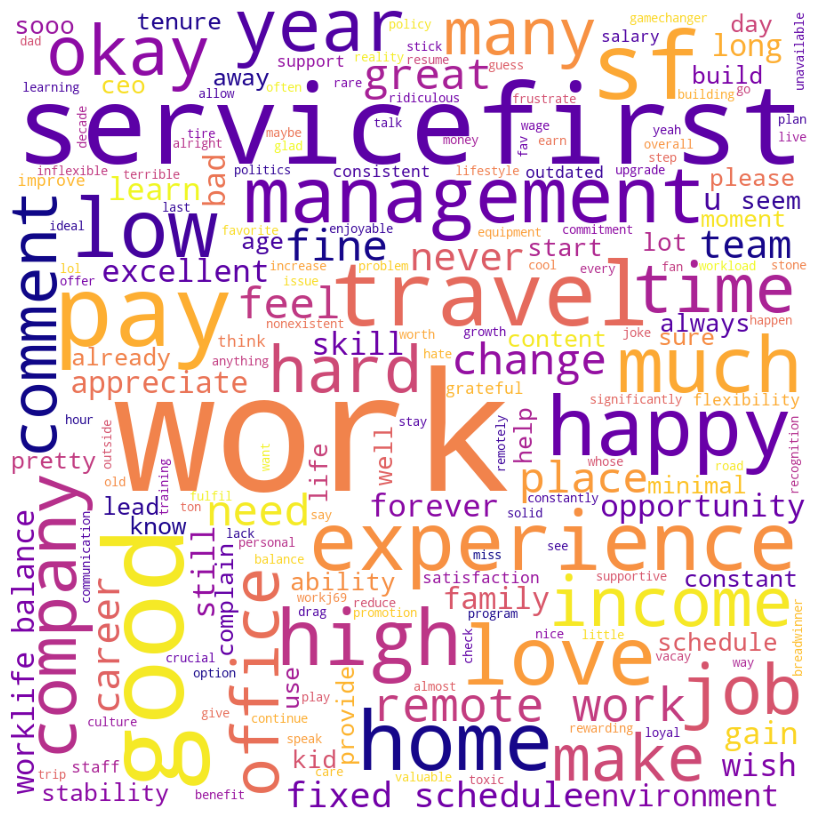

In [83]:
# Import workcloud 
from wordcloud import WordCloud 

#First we need to create a string variable of the tokens2 list
tokens2_string = ' '.join(tokens2)

# Set the colour palette.
sns.set(color_codes=True)

# Create a WordCloud.
wordcloud = WordCloud(width = 900,
                      height = 900, 
                      background_color ='white', 
                      colormap='plasma', 
                      min_font_size = 10).generate(tokens2_string) 

# Plot the word cloud.                        
plt.figure(figsize = (8, 8),
           facecolor = None) 

plt.imshow(wordcloud) 
plt.axis('off') 
plt.tight_layout(pad = 0) 

#save the plot
plt.savefig('wordcloud_1.png')

#show the plot
plt.show()


>The largest word in the wordcloud is work, followed by servicefirst/good

##### Frequency Plot

In [84]:
# Create a dataframe that includes the frequency of the words
# Import the Counter class.
from collections import Counter

# Generate a DataFrame from Counter.
freq = pd.DataFrame(Counter(tokens2).most_common(30),
                      columns=['Word', 'Frequency']).set_index('Word')

# Preview the data.
freq

,Frequency
Word,
work,27
good,19
servicefirst,18
pay,15
sf,13
travel,12
low,10
love,10
home,10


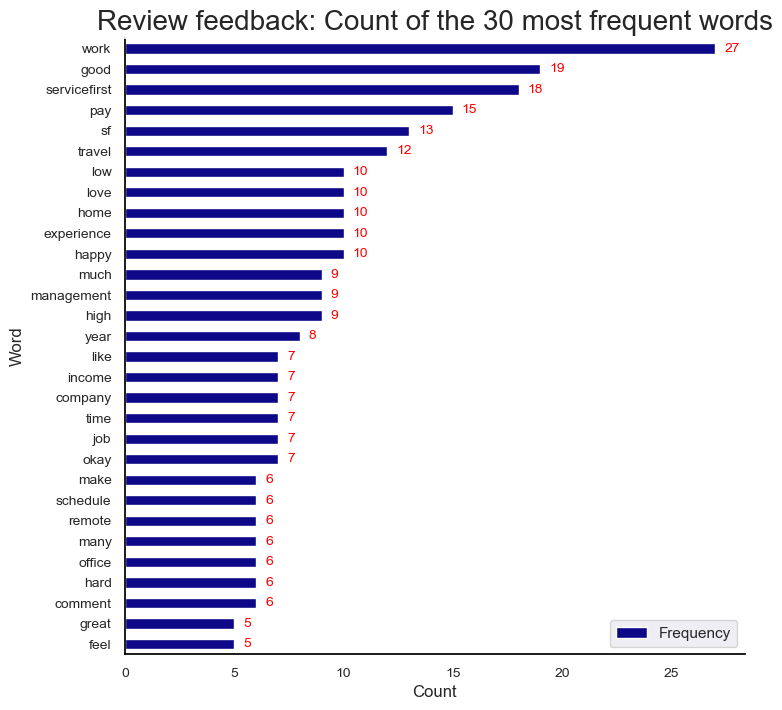

In [85]:
# Sort the dataframe by frequency in descending order
freq_sorted = freq.sort_values(by=freq.columns[0], ascending=True)

# Plot the dataframe
ax = freq_sorted.plot(kind='barh',
                      figsize=(8, 8),
                      fontsize=10,
                      colormap='plasma',
                     )

# Set the labels
ax.set_xlabel('Count', fontsize=12)
ax.set_ylabel('Word', fontsize=12)
ax.set_title("Review feedback: Count of the 30 most frequent words", fontsize=20)

# Set white background and make the bottom and left edge visible
ax.set_facecolor('white')  # Set plot background to white
plt.gca().spines['bottom'].set_edgecolor('black')
plt.gca().spines['left'].set_edgecolor('black')

# Draw the bar labels
for i in ax.patches:
    ax.text(i.get_width() + 0.41, 
            i.get_y() + 0.1, 
            str(round(i.get_width(), 2)), 
            fontsize=10, 
            color='red') 

# Save the plot as a PNG file
plt.savefig('frequent_words1.png', facecolor='white', bbox_inches='tight')

# Show the plot
plt.show()


>As found in the wordcloud, the most frequent word is 'work' followed by 'servicefirst', then 'good'. However, 'ServiceFirst' and 'sf' (abbreviation of servicefirst) is the name of the company, so these will be removed.

In [86]:
# Define the words to remove
company_names = {"servicefirst", "sf"}

# Filter tokens2 to exclude the company names
tokens3 = [token for token in tokens2 if token.lower() not in company_names]

# View the updated tokens3 list
print(len(tokens3))
tokens3[:20]

564


['stick',
 'low',
 'wage',
 'year',
 'management',
 'seem',
 'care',
 'great',
 'start',
 'career',
 'learn',
 'lot',
 'learn',
 'ton',
 'love',
 'decade',
 'ability',
 'work',
 'home',
 'gamechanger']

In [87]:
#check the frequencie
# Calculate the frequency distribution.
fdist = FreqDist(tokens3)

# Preview data.
fdist

FreqDist({'work': 27, 'good': 19, 'pay': 15, 'travel': 12, 'low': 10, 'love': 10, 'home': 10, 'experience': 10, 'happy': 10, 'management': 9, ...})

>the company name is no longer in our list

Replot our wordcloud and frequency plot

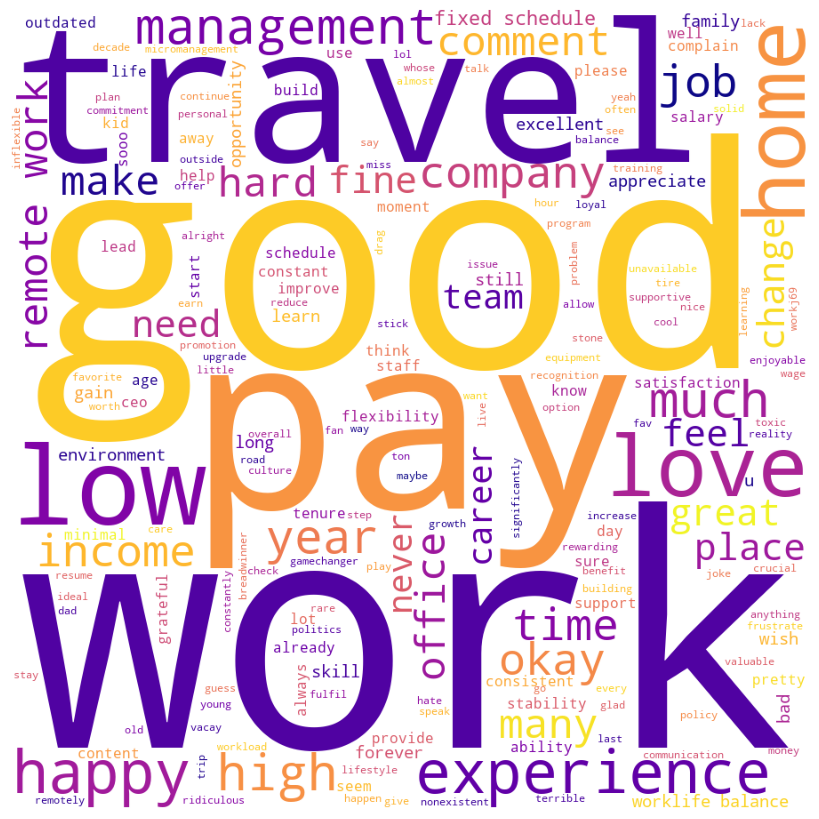

In [88]:
#Workcloud
#First we need to create a string variable of the tokens3 list
tokens3_string = ' '.join(tokens3)

# Set the colour palette.
sns.set(color_codes=True)

# Create a WordCloud.
wordcloud = WordCloud(width = 900,
                      height = 900, 
                      background_color ='white', 
                      colormap='plasma', 
                      min_font_size = 10).generate(tokens3_string) 

# Plot the word cloud.                        
plt.figure(figsize = (8, 8),
           facecolor = None) 

plt.imshow(wordcloud) 
plt.axis('off') 
plt.tight_layout(pad = 0) 

#save the plot
plt.savefig('wordcloud_2.png')

#show the plot
plt.show()


>work, good, travel, pay are the largest words in the wordcloud indicating the most frequent words

In [89]:
# Generate a DataFrame from Counter.
freq2 = pd.DataFrame(Counter(tokens3).most_common(30),
                      columns=['Word', 'Frequency']).set_index('Word')

# Preview the data.
freq2

,Frequency
Word,
work,27
good,19
pay,15
travel,12
low,10
love,10
home,10
experience,10
happy,10


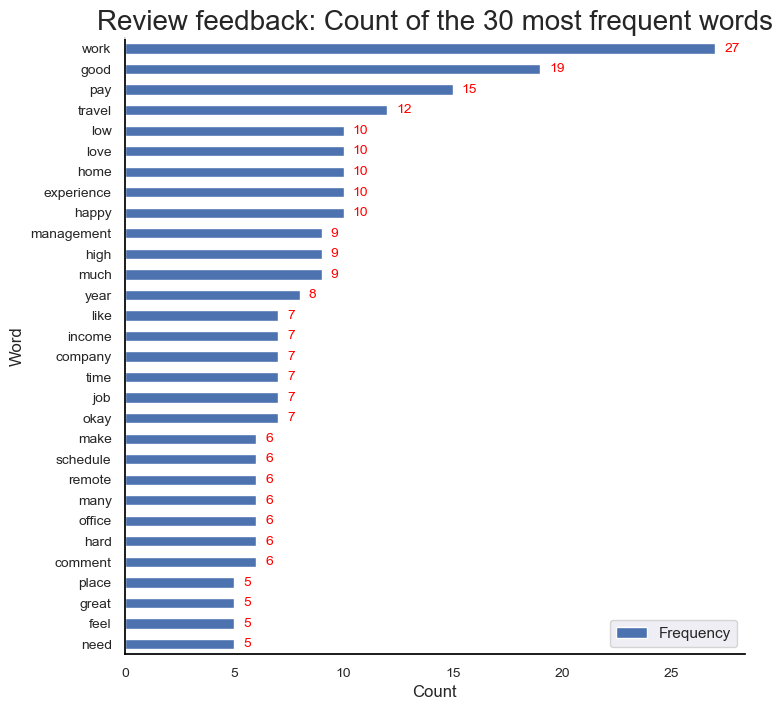

In [90]:
# Sort the dataframe by frequency in descending order
freq_sorted = freq2.sort_values(by=freq2.columns[0], ascending=True)

# Plot the dataframe
ax = freq_sorted.plot(kind='barh',
                      figsize=(8, 8),
                      fontsize=10,
                     # colormap='plasma',
                     )

# Set the labels
ax.set_xlabel('Count', fontsize=12)
ax.set_ylabel('Word', fontsize=12)
ax.set_title("Review feedback: Count of the 30 most frequent words", fontsize=20)

# Set white background and make the bottom and left edge visible
ax.set_facecolor('white')  # Set plot background to white
plt.gca().spines['bottom'].set_edgecolor('black')
plt.gca().spines['left'].set_edgecolor('black')

# Draw the bar labels
for i in ax.patches:
    ax.text(i.get_width() + 0.41, 
            i.get_y() + 0.1, 
            str(round(i.get_width(), 2)), 
            fontsize=10, 
            color='red') 

# Save the plot as a PNG file
plt.savefig('frequent_words2.png', facecolor='white', bbox_inches='tight')

# Show the plot
plt.show()


>The output indicates the top 5 most frequent words are 'work', 'good', 'pay', 'travel', low.
>
However, although we have been able to obtain the frequency of the words, we are unable to draw conclusions as yet we regard to the sentiment.

#### d) Review sentiment
Two methods were used to conduct the sentiment analysis of the Review column (TextBlob and Nltk Vader). Please review final report for reasoning. 

#### TextBlob
The TextBlob module will be used to review polarity (i.e., sentiment) and subjectivity.

 - The polarity measure provides the sentiment or emotional tone of the text, indicating how positive, negative or neutral. The value ranges from -1 (most negative) to +1 (most positive). A value of 0 is neutral.

 - The subjectivity measure provides how subjective or objective a statement (i.e., whether it is an opinion or fact). The value ranges from 0 (completely objective) to + 1 (completely subjective)

In [91]:
# Import the textblob module
from textblob import TextBlob

#Drop Tokens column from the dataframe
survey_s.drop(columns=['Tokens'], inplace=True)

In [92]:
#view survey_s
survey_s.head()

,Review,Cluster
0,stuck with low wages for years management does not seem to care,2
1,servicefirst is a great start for my career learning a lot,1
2,i am learning a ton here love it,1
3,i have been with servicefirst for over a decade and the ability to work from home has been a gamechanger for my worklife balance,0
4,i feel like i never see my kids because i am always traveling for work,2


#### Polarity

In [93]:
# Define a function to extract a polarity score for the comment.
def generate_polarity(comment):
    return TextBlob(comment).sentiment[0]

# Populate a new column with polarity scores for each comment.
survey_s['Polarity'] = survey_s['Review'].apply(generate_polarity)

# Preview the result.
survey_s['Polarity'].head()

0    0.0
1    0.8
2    0.5
3    0.3
4    0.0
Name: Polarity, dtype: float64

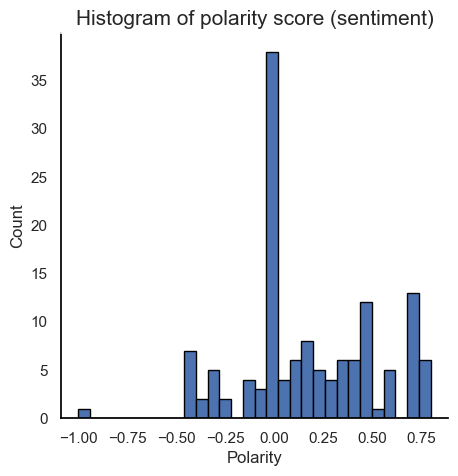

In [94]:
#create a histogram of the polarity score
ax = survey_s['Polarity'].hist(figsize=(5, 5), 
                               bins=30, 
                               edgecolor='black')

# Set the labels.
ax.set_xlabel('Polarity', fontsize=12)
ax.set_ylabel('Count', fontsize=12)
ax.set_title('Histogram of polarity score (sentiment)', fontsize=15)

# Set white background and make the bottom and left edge visible
ax.set_facecolor('white')  
plt.gca().spines['bottom'].set_edgecolor('black')
plt.gca().spines['left'].set_edgecolor('black')

plt.show()

> The histogram indicates that the highest frequency of the comments have been scored as neutral. There are few particularly negative comments, but otherwise most are positive.

In [95]:
#view the descriptive statistics of the Polarity score
survey_s['Polarity'].describe().round(2)

count    138.00
mean       0.18
std        0.35
min       -1.00
25%        0.00
50%        0.12
75%        0.50
max        0.80
Name: Polarity, dtype: float64

> The mean polarity score = 0.18 which just above neutral and 25% of the comments are above a polarity score of 0.5.

#### Subjectivity

In [96]:
# Define a function to extract a subjectivity score for the comment.
def generate_subjectivity(comment):
    return TextBlob(comment).sentiment[1]

# Populate a new column with subjectivity scores for each comment.
survey_s['Subjectivity'] = survey_s['Review'].apply(generate_subjectivity)

# Preview the result.
survey_s['Subjectivity'].head()

0    0.30
1    0.75
2    0.60
3    0.00
4    0.00
Name: Subjectivity, dtype: float64

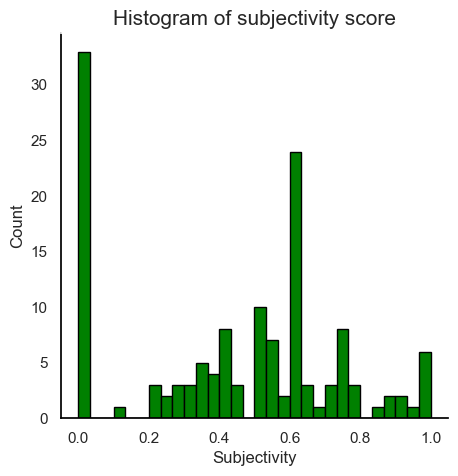

In [97]:
#create a histogram of the subjectivity score
ax = survey_s['Subjectivity'].hist(figsize=(5, 5), 
                               bins=30, 
                               color='green',    
                               edgecolor='black')

# Set the labels.
ax.set_xlabel('Subjectivity', fontsize=12)
ax.set_ylabel('Count', fontsize=12)
ax.set_title('Histogram of subjectivity score', fontsize=15)

# Set white background and make the bottom and left edge visible
ax.set_facecolor('white')  
plt.gca().spines['bottom'].set_edgecolor('black')
plt.gca().spines['left'].set_edgecolor('black')

plt.show()

> The histogram indicates that the highest frequency of the comments have been scored as zero ie objective comments. 

In [98]:
#view the descriptive statistics of the Subjectivity score
survey_s['Subjectivity'].describe().round(2)

count    138.00
mean       0.43
std        0.30
min        0.00
25%        0.20
50%        0.50
75%        0.60
max        1.00
Name: Subjectivity, dtype: float64

>The mean subjectivity score is 0.4 indicating that most of the comments are opinions and not objective.

In [99]:
#View the dataframe
survey_s.head()

,Review,Cluster,Polarity,Subjectivity
0,stuck with low wages for years management does not seem to care,2,0.0,0.30
1,servicefirst is a great start for my career learning a lot,1,0.8,0.75
2,i am learning a ton here love it,1,0.5,0.60
3,i have been with servicefirst for over a decade and the ability to work from home has been a gamechanger for my worklife balance,0,0.3,0.00
4,i feel like i never see my kids because i am always traveling for work,2,0.0,0.00


In [100]:
#save the output file as a csv file
survey_s.to_csv('survey_s.csv')

#### Obtain the top positive and top negative statements

In [101]:
# Sort the DataFrame by polarity in ascending order to get the most negative statements.
top_negative = survey_s.sort_values(by='Polarity', ascending=True).head(20)

# Sort the DataFrame by polarity in descending order to get the most positive statements.
top_positive = survey_s.sort_values(by='Polarity', ascending=False).head(20)

# Expand the column width to display the full statement.
pd.set_option('display.max_colwidth', None)

# Display the results.
print("Top 20 Negative Statements:")
print(top_negative)

print("\nTop 20 Positive Statements:")
print(top_positive)

Top 20 Negative Statements:
                                                                          Review  \
43                                                 office politics are the worst   
63                                        the equipment we work with is outdated   
128                                                   team collaboration is poor   
108                                                             pay is not great   
8            been here forever but the pay is still terrible too much travel too   
99                                  company policies are outdated and inflexible   
29                       i am not happy i have spoken to my team lead about this   
87                been here forever but the lack of career growth is frustrating   
73                        management is not good at all they are not experienced   
48                                         the ceo is not good please change him   
47                                              

>The top 20 positive and top 20 negative reviews have subjectivity scores above zero reflecting personal feelings rather than objective facts. The common themes for the positive comments are the opportunities for career and skill development and good pay. It was also found that Cluster 1 dominated the positive reviews, which had a medium Satisfaction score, who were the young employees early in their career and education (Low Group). The common themes for the negative group focused on office politics, poor team collaboration, management inaccessibility, low pay and lack of career growth. In addition, complaints about excessive travel, long office hours and difficulty balancing work and personal commitments. The negative comments were dominated by Cluster 2 which were employees that travelled frequently, and were in the medium bracket (medium tenure, income, age and education).

In [102]:
#Save the top 20 positive and negative feedback to csv file
top_negative.to_csv('top_negative.csv')
top_positive.to_csv('top_positive.csv')

#### NLTK Vader
NLTK Vader sentiment analysis tool has been found to be is better at predicting negative sentiments and is better suited for informal text. It provides more nuanced sentiment intensity scores. Vader from the nltk library categorises text as either positive, negative or neutral to then determine a weighted summation score called ‘compound’ which ranges from -1 (highly negative) to 1 (highly positive). 

In [103]:
from nltk.sentiment.vader import SentimentIntensityAnalyzer

# Download the VADER lexicon 
nltk.download('vader_lexicon')


[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\Dimi\AppData\Roaming\nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


True

In [104]:
#Create an instance of the SentimentIntensityAnalyzer class.
sia = SentimentIntensityAnalyzer()

# Apply sentiment analysis to each review in the 'Review' column
survey_s['sentiment'] = survey_s['Review'].apply(lambda x: sia.polarity_scores(x))

#view the output
survey_s.head()

,Review,Cluster,Polarity,Subjectivity,sentiment
0,stuck with low wages for years management does not seem to care,2,0.0,0.30,"{'neg': 0.428, 'neu': 0.572, 'pos': 0.0, 'compound': -0.6935}"
1,servicefirst is a great start for my career learning a lot,1,0.8,0.75,"{'neg': 0.0, 'neu': 0.661, 'pos': 0.339, 'compound': 0.6249}"
2,i am learning a ton here love it,1,0.5,0.60,"{'neg': 0.0, 'neu': 0.543, 'pos': 0.457, 'compound': 0.6369}"
3,i have been with servicefirst for over a decade and the ability to work from home has been a gamechanger for my worklife balance,0,0.3,0.00,"{'neg': 0.0, 'neu': 0.897, 'pos': 0.103, 'compound': 0.3182}"
4,i feel like i never see my kids because i am always traveling for work,2,0.0,0.00,"{'neg': 0.0, 'neu': 0.815, 'pos': 0.185, 'compound': 0.3612}"


>The output of the sentiment intensity analyser provides the following (sentiment column):
> - neg: The proportion of negative sentiment in the text.
> - neu: The proportion of neutral sentiment in the text.
> - pos: The proportion of positive sentiment in the text.
> - compound: A normalised sentiment score ranging from -1 (most negative) to +1 (most positive). It provides an overall measure of the sentiment.
>
The next step is to split these values into four separate columbns

In [105]:
# Extract positive, negative, and compound scores into separate columns
survey_s['positive'] = survey_s['sentiment'].apply(lambda x: x['pos'])
survey_s['neutral'] = survey_s['sentiment'].apply(lambda x: x['neu'])
survey_s['negative'] = survey_s['sentiment'].apply(lambda x: x['neg'])
survey_s['compound'] = survey_s['sentiment'].apply(lambda x: x['compound'])

# Drop the 'sentiment' column
survey_s.drop(columns=['sentiment'], inplace=True)

#view the output
survey_s.head()

,Review,Cluster,Polarity,Subjectivity,positive,neutral,negative,compound
0,stuck with low wages for years management does not seem to care,2,0.0,0.30,0.000,0.572,0.428,-0.6935
1,servicefirst is a great start for my career learning a lot,1,0.8,0.75,0.339,0.661,0.000,0.6249
2,i am learning a ton here love it,1,0.5,0.60,0.457,0.543,0.000,0.6369
3,i have been with servicefirst for over a decade and the ability to work from home has been a gamechanger for my worklife balance,0,0.3,0.00,0.103,0.897,0.000,0.3182
4,i feel like i never see my kids because i am always traveling for work,2,0.0,0.00,0.185,0.815,0.000,0.3612


>The sentiment column has correctly been split into four columns, positive, neutral, negative and compound (which is overall weighted summation of positive, neutral and negative scores).
>
The next step is to create a visualisation of the distribution.

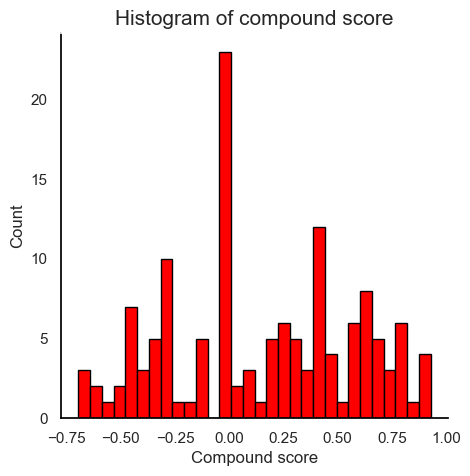

In [106]:
#create a histogram of the compound score
ax = survey_s['compound'].hist(figsize=(5, 5), 
                               bins=30, 
                               color='red',    
                               edgecolor='black')

# Set the labels.
ax.set_xlabel('Compound score', fontsize=12)
ax.set_ylabel('Count', fontsize=12)
ax.set_title('Histogram of compound score', fontsize=15)

# Set white background and make the bottom and left edge visible
ax.set_facecolor('white')  
plt.gca().spines['bottom'].set_edgecolor('black')
plt.gca().spines['left'].set_edgecolor('black')

plt.show()

>The histogram indicates that the highest frequency of the comments have been scored as neutral with a much more even distribution either side compared to the polarity distribution using the Textblob method.

In [107]:
#view the descriptive statistics of the Compound score
survey_s['compound'].describe().round(2)

count    138.00
mean       0.16
std        0.43
min       -0.70
25%       -0.18
50%        0.15
75%        0.47
max        0.93
Name: compound, dtype: float64

>The mean compound score was 0.16, thus overall positive, with 25% above a score of 0.5.

In [108]:
#save the output file as a csv file
survey_s.to_csv('survey_s2.csv')

#### Obtain the top positive and top negative statements based on the Compound Score
The polarity score and subjectivity score were also included in the final column. 

In [109]:
# Sort the DataFrame by compound value in ascending order to get the most negative statements.
top_negative2 = survey_s.sort_values(by='compound', ascending=True).head(20)

# Sort the DataFrame by compound value in descending order to get the most positive statements.
top_positive2 = survey_s.sort_values(by='compound', ascending=False).head(20)

# Expand the column width to display the full statement.
pd.set_option('display.max_colwidth', None)

# Display the results.
print("Top 20 Negative Statements:")
print(top_negative2[['Review', 'Polarity', 'Subjectivity', 'Cluster', 'compound']])

print("\nTop 20 Positive Statements:")
print(top_positive2[['Review', 'Polarity', 'Subjectivity', 'Cluster', 'compound']])

Top 20 Negative Statements:
                                                                                          Review  \
8                            been here forever but the pay is still terrible too much travel too   
0                                stuck with low wages for years management does not seem to care   
22                             i hate being away from home so much office all the time is a drag   
43                                                                 office politics are the worst   
15                                                         low income  it is not making me happy   
108                                                                             pay is not great   
87                                been here forever but the lack of career growth is frustrating   
48                                                         the ceo is not good please change him   
114  it is okay but i think they will have a problem with younger staff 

> NLTK Vader seems to outperforms Textblob in analysing sentiment, especially for longer statements.
Example 1: “I appreciate the high income and the support for remote work…”
Textblob: Polarity score = 0 (neutral)
NLTK: Compound score = 0.8 (positive)
Example 2: “My team lead needs more experience…”
Textblob: Polarity score = 0 (neutral)
NLTK: Compound score = -0.5 (negative)
Sentiment clustering:

>Most positive reviews fall in Cluster 0 (High Group) and Cluster 1 (Low Group). These groups represent employees who travel infrequently or not at all.
>Most negative reviews are concentrated in Cluster 2 (Medium Group). This group includes employees with medium tenure, frequent travel, and moderate satisfaction.
>
>Themes in positive reviews:
> - Flexibility, remote work, high income, and opportunities for skill development.
> - Supportive work environment with consistent schedules enhancing work-life balance.
> - Long-tenured employees feel rewarded.
> - Newer staff value opportunities to build skills and gain experience.

>Themes in negative reviews:
> - Dissatisfaction with low pay, excessive travel, and limited career progression.
> - Leadership issues such as inexperienced management and poor team collaboration.
> - Work-life balance challenges due to excessive travel and heavy workloads, particularly for employees with family responsibilities.

In [110]:
#Save the top 20 positive and negative feedback based on the NLTK Vader modelling to csv file
top_negative2.to_csv('top_negative2.csv')
top_positive2.to_csv('top_positive2.csv')